In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve

In [46]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH = "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [47]:
df_anomalies = pd.read_csv(LABELS)

In [48]:
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   chan_id            82 non-null     object
 1   spacecraft         82 non-null     object
 2   anomaly_sequences  82 non-null     object
 3   class              82 non-null     object
 4   num_values         82 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.3+ KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

From now on, we will use "channel" as equivalence of "feature" of each telemtry, which should not be confuse with "channel_id" of the labels dataset, which is referred to telemetry itself.

In [49]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Selecting only SMAP spacecraft, we have 54 telemetries, we probably should work with one at the time. Let's see how an anomaly is made:

In [50]:
np.random.seed(26)
telemetry_pos = np.random.randint(0,54)
print(telemetry_pos)

telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(telemetry_name)

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')
print(test_data.shape)

53
A-9
(8434, 25)


In [51]:
anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(anomaly)

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1]) #just to plot

[[4569 8433]]


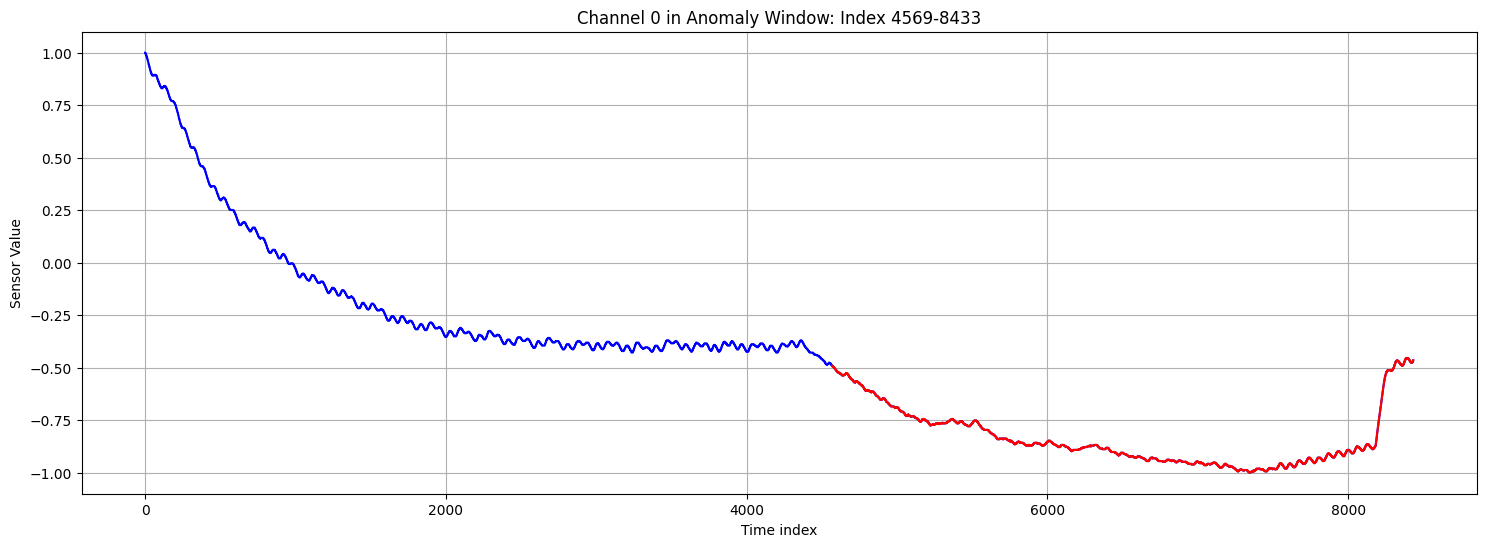

In [52]:
plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This is a **contextual** anomaly as an anomalous trend appears in telemeyry.

## PREPROCESSING

1. EDA iniziale sui file train
2. controllo NaN / Inf
3. controllo feature costanti
4. rimozione feature costanti
5. split temporale train / validation
6. scaling fit solo sul train
7. PCA opzionale fit solo sul train
8. windowing

First we apply preprocessing pipeline on training set, then in test set.

In [53]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

In [54]:
train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.nanstd(X, axis=0) #std among columns, nanstd ignores nan val
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training set shows that the data are generally clean from a missing-value perspective. No NaN or infinite values were found across the considered telemetry channels, so no imputation or removal of corrupted samples is required at this stage.

However, the dataset presents some relevant preprocessing issues. First, the telemetry streams have *different temporal* lengths: most channels contain around 2600–2880 time steps, while some channels are much shorter. This affects the windowing procedure, because shorter series generate fewer training windows and may be less informative for sequence-based models.

Second, all channels have 25 features, but several of these features *are constant over time* within each channel. In some cases, only a few features are constant, while in others almost all features do not vary. This is important because **constant features do not carry temporal information and may unnecessarily increase the dimensionality of the input**. They can also affect scaling and model training if not handled explicitly. --> `PCA`

A special case is represented by channels such as `D-12` and `D-13`, where all 25 features are constant over time. This does not necessarily mean that the whole matrix contains a single repeated value: different columns may have different constant values. However, from a temporal modeling perspective, these channels contain no dynamic information in the training set, and therefore require special attention.

In [55]:
train_summary_df.describe()

,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
count,54.000000,54.0,54.0,54.0,54.000000,54.000000,54.000000,54.000000,54.000000
mean,2555.629630,25.0,0.0,0.0,10.388889,-0.857037,0.962963,0.005461,0.200148
std,656.221784,0.0,0.0,0.0,5.137420,0.333747,0.190626,0.027075,0.041398
min,312.000000,25.0,0.0,0.0,6.000000,-1.000000,0.000000,-0.040000,0.074036
25%,2596.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,-0.016257,0.175010
50%,2851.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,0.003124,0.201878
75%,2880.000000,25.0,0.0,0.0,12.750000,-1.000000,1.000000,0.023131,0.240640
max,2881.000000,25.0,0.0,0.0,25.000000,0.000000,1.000000,0.063826,0.252260


The preprocessing pipeline is applied independently to each SMAP telemetry channel. First, the original training sequence is split into training and validation subsets using a temporal split, without shuffling, in order to avoid temporal leakage. Constant features are detected only on the training subset and then removed from both training and validation data. This avoids using information from the validation period during feature selection.

After removing constant features, the remaining variables are separated into binary and continuous features, using only the training subset to identify their type. Continuous features are standardized with a `StandardScaler` fitted only on the training subset, and the same transformation is then applied to the validation subset. Binary features are not standardized, since standardization would transform their original 0/1 representation into frequency-dependent real values. Instead, they are either kept as 0/1 variables or mapped to -1/1 in order to obtain a zero-centered binary encoding without distorting their binary nature.

Optionally, PCA can be fitted on the processed training data and then applied to the validation data, in order to reduce dimensionality while preserving a fixed fraction of the variance. PCA is also fitted only on the training subset to avoid information leakage.

Finally, both training and validation sequences are converted into overlapping temporal windows, which represent the input format required by sequence-based reconstruction or forecasting models.

In [56]:
def temporal_train_val_split(X, val_ratio=0.2):
    """
    Temporal split: first part for training, last part for validation.
    """
    split_idx = int(len(X) * (1 - val_ratio))
    X_train = X[:split_idx]
    X_val = X[split_idx:]
    
    return X_train, X_val

def detect_binary_features(X):
    """
    Detect binary columns using only the training split.
    A feature is considered binary if its unique values are contained in {0, 1}.
    """
    binary_mask = []

    for j in range(X.shape[1]):
        unique_values = np.unique(X[:, j])
        is_binary = set(unique_values).issubset({0, 1})
        binary_mask.append(is_binary)

    return np.array(binary_mask)

def make_windows(X, window_size=30, stride=1):
    """
    Convert a time series X of shape (T, d)
    into windows of shape (n_windows, window_size, d).
    """
    if len(X) < window_size:
        return None
    
    windows = []
    
    for start in range(0, len(X) - window_size + 1, stride):
        end = start + window_size
        windows.append(X[start:end])
    
    return np.stack(windows)

### Windowing

After the temporal split, each telemetry sequence is converted into overlapping time windows. This step is needed because the model should not observe each time step independently, but should instead learn short temporal patterns in the recent history of the signal.

Given a preprocessed sequence:

$X \in \mathbb{R}^{T \times d}$

where T is the number of time steps and d is the number of retained features, we construct windows of length w:

$W_t = [X_t, X_{t+1}, \dots, X_{t+w-1}]$

Each window therefore has shape:

$w \times d$

In this project, we use `window_size = 30` and `stride = 1`, meaning that consecutive windows overlap and are shifted by one time step. Therefore, the number of generated windows is:

$N_{\text{windows}} = T - w + 1$

#### Choice of the stride

In the windowing procedure, the stride controls how far the sliding window is shifted at each step. With `stride = 1`, two consecutive windows overlap almost completely and differ by only one time step. This produces the maximum number of training samples and preserves the highest temporal resolution.

This choice is suitable for anomaly detection because anomalies may be short, localized, or only visible in a narrow temporal region. Using a larger stride would reduce the number of windows and the computational cost, but it could also make the model less sensitive to short anomalous intervals or produce less precise anomaly localization.

Since the SMAP telemetry sequences are not extremely large, using `stride = 1` is a reasonable default choice for the first version of the pipeline. Larger strides can be considered as a computationally cheaper alternative and compared in an ablation study, for example by testing whether `stride = 5` significantly reduces performance while decreasing the number of generated windows.

For example, if a training split contains 2304 time steps and the window size is 30, the number of windows is:

$ 2304 - 30 + 1 = 2275 $

The final input shape for a channel is therefore:

$N_{\text{windows}} \times 30 \times d$

This representation allows the model to learn temporal dependencies and local patterns in the telemetry stream, which is essential for detecting anomalies that may not be visible from a single isolated time step.

In [57]:
def preprocess_single_channel(
    channel_id,
    train_path,
    val_ratio=0.2,
    window_size=30,
    stride=1,
    map_binary = True,
    drop_constant_features=True,
    use_pca=False,
    pca_variance=0.95
):
    # -------------------------
    # Load raw training sequence
    # -------------------------
    path = train_path + "/" + channel_id + ".npy"
    X_raw = np.load(path)
    
    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_raw).sum()
    inf_count = np.isinf(X_raw).sum()
    
    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found.")
    
    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found.")
    
    # -------------------------
    # Temporal train/validation split
    # -------------------------
    X_train_raw, X_val_raw = temporal_train_val_split(X_raw, val_ratio=val_ratio)
    
    # -------------------------
    # Detect constant features on TRAIN only
    # -------------------------
    feature_std_train = np.std(X_train_raw, axis=0)
    constant_mask = feature_std_train == 0
    keep_mask = ~constant_mask
    
    n_constant_features = int(constant_mask.sum())
    constant_feature_indices = np.where(constant_mask)[0]
    kept_feature_indices = np.where(keep_mask)[0]
    
    # If all features are constant, skip this channel
    if keep_mask.sum() == 0:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_all_features_constant",
            "raw_shape": X_raw.shape,
            "n_constant_features": n_constant_features,
            "constant_feature_indices": constant_feature_indices,
        }
    
    # -------------------------
    # Drop constant features
    # -------------------------
    if drop_constant_features:
        X_train_raw = X_train_raw[:, keep_mask]
        X_val_raw = X_val_raw[:, keep_mask]
    else:
        kept_feature_indices = np.arange(X_raw.shape[1])

    # -------------------------
    # Detect binary and continuous features on TRAIN only
    # -------------------------
    binary_mask = detect_binary_features(X_train_raw)
    continuous_mask = ~binary_mask
    binary_feature_indices_after_drop = np.where(binary_mask)[0]
    continuous_feature_indices_after_drop = np.where(continuous_mask)[0]
    n_binary_features = int(binary_mask.sum())
    n_continuous_features = int(continuous_mask.sum())
    
    # -------------------------
    # Scaling (continuos): fit only on train
    # -------------------------

    X_train_processed_parts = []
    X_val_processed_parts = []

    scaler = None

    if n_continuous_features > 0:
        scaler = StandardScaler()
        X_train_cont = X_train_raw[:, continuous_mask]
        X_val_cont = X_val_raw[:, continuous_mask]
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)
        X_val_cont_scaled = scaler.transform(X_val_cont)
        X_train_processed_parts.append(X_train_cont_scaled)
        X_val_processed_parts.append(X_val_cont_scaled)

    # -------------------------
    # Mapping (bianry)
    # -------------------------

    if n_binary_features > 0:
        X_train_bin = X_train_raw[:, binary_mask]
        X_val_bin = X_val_raw[:, binary_mask]

        if map_binary:
            X_train_bin = 2 * X_train_bin - 1
            X_val_bin = 2 * X_val_bin - 1

        X_train_processed_parts.append(X_train_bin)
        X_val_processed_parts.append(X_val_bin)

    # Concatenate continuous-scaled + binary-encoded features
    X_train_processed = np.concatenate(X_train_processed_parts, axis=1)
    X_val_processed = np.concatenate(X_val_processed_parts, axis=1)
    
    # -------------------------
    # Optional PCA: fit only on train
    # -------------------------
    pca = None
    
    if use_pca:
        pca = PCA(n_components=pca_variance)
        X_train_processed = pca.fit_transform(X_train_processed)
        X_val_processed = pca.transform(X_val_processed)
        n_components_pca = pca.n_components_
        explained_variance = float(pca.explained_variance_ratio_.sum())
    else:
        X_train_processed = X_train_processed
        X_val_processed = X_val_processed
        n_components_pca = np.NaN
        explained_variance = None
    
    # -------------------------
    # Windowing
    # -------------------------
    X_train_win = make_windows(X_train_processed, window_size=window_size, stride=stride)
    X_val_win = make_windows(X_val_processed, window_size=window_size, stride=stride)
    
    if X_train_win is None or X_val_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_too_short_after_split",
            "raw_shape": X_raw.shape,
            "train_shape": X_train_processed.shape,
            "val_shape": X_val_processed.shape,
        }
    
    # -------------------------
    # Output dictionary
    # -------------------------
    data = {
        "X_train": X_train_win,
        "X_train_seq": X_train_processed,
        "X_val": X_val_win,
        "X_val_seq": X_val_processed,
        "scaler": scaler,
        "pca": pca,
        "kept_feature_indices": kept_feature_indices,
        "constant_feature_indices": constant_feature_indices,
        "continuous_mask": continuous_mask,
        "map_binary": map_binary,
        "binary_mask": binary_mask,
    }
    
    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_raw.shape,
        "train_raw_shape": X_train_raw.shape,
        "val_raw_shape": X_val_raw.shape,
        "train_windows_shape": X_train_win.shape,
        "val_windows_shape": X_val_win.shape,
        "n_original_features": int(X_raw.shape[1]),
        "n_constant_features": n_constant_features,
        "n_kept_features": len(kept_feature_indices),
        "use_pca": use_pca,
        "n_components_after_pca": n_components_pca,
        "pca_explained_variance": explained_variance,
    }
    
    return data, info

We try first without PCA, then with PCA.

In [58]:
VAL_RATIO = 0.2
WINDOW_SIZE = 30
STRIDE = 1

USE_PCA = False          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = True

preprocessed_data = {}
preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary.append(info)
    
    if data is not None:
        preprocessed_data[ch] = data
        

preprocessing_summary_df = pd.DataFrame(preprocessing_summary)

if "constant_feature_indices" in preprocessing_summary_df.columns:
    preprocessing_summary_df = preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance
0,A-1,ok,"(2880, 25)","(2304, 19)","(576, 19)","(2275, 30, 19)","(547, 30, 19)",25.0,6,19.0,False,NaN,NaN
1,A-2,ok,"(2648, 25)","(2118, 18)","(530, 18)","(2089, 30, 18)","(501, 30, 18)",25.0,7,18.0,False,NaN,NaN
2,A-3,ok,"(2736, 25)","(2188, 18)","(548, 18)","(2159, 30, 18)","(519, 30, 18)",25.0,7,18.0,False,NaN,NaN
3,A-4,ok,"(2690, 25)","(2152, 18)","(538, 18)","(2123, 30, 18)","(509, 30, 18)",25.0,7,18.0,False,NaN,NaN
4,A-5,ok,"(705, 25)","(564, 11)","(141, 11)","(535, 30, 11)","(112, 30, 11)",25.0,14,11.0,False,NaN,NaN
5,A-6,ok,"(682, 25)","(545, 11)","(137, 11)","(516, 30, 11)","(108, 30, 11)",25.0,14,11.0,False,NaN,NaN
6,A-7,ok,"(2879, 25)","(2303, 10)","(576, 10)","(2274, 30, 10)","(547, 30, 10)",25.0,15,10.0,False,NaN,NaN
7,A-8,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,NaN,NaN
8,A-9,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,NaN,NaN
9,B-1,ok,"(2435, 25)","(1948, 12)","(487, 12)","(1919, 30, 12)","(458, 30, 12)",25.0,13,12.0,False,NaN,NaN


Each raw training sequence originally contains 25 features, but several features are constant over time within individual channels. These constant features were detected using only the training split and removed before scaling, in order to avoid adding non-informative dimensions to the model.

The temporal split preserves the chronological order of the data, using the first 80% of each sequence for training and the last 20% for validation. After feature filtering and standardization, the sequences were converted into overlapping windows of length 30. The resulting window shapes are consistent with the expected formula T - window_size + 1.

Most channels were successfully preprocessed. Channels `D-12` and `D-13` were skipped because all their features were constant in the training split, leaving no dynamic information to model. PCA was not applied in this preprocessing run, so the PCA-related columns are intentionally empty.

In [59]:
VAL_RATIO = 0.2
WINDOW_SIZE = 30
STRIDE = 1

USE_PCA = True          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = True

preprocessed_data_pca = {}
preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary_pca.append(info)
    
    if data is not None:
        preprocessed_data_pca[ch] = data

pca_preprocessing_summary_df = pd.DataFrame(preprocessing_summary_pca)

if "constant_feature_indices" in pca_preprocessing_summary_df.columns:
    pca_preprocessing_summary_df = pca_preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(pca_preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance
0,A-1,ok,"(2880, 25)","(2304, 19)","(576, 19)","(2275, 30, 5)","(547, 30, 5)",25.0,6,19.0,True,5.0,0.960289
1,A-2,ok,"(2648, 25)","(2118, 18)","(530, 18)","(2089, 30, 5)","(501, 30, 5)",25.0,7,18.0,True,5.0,0.971297
2,A-3,ok,"(2736, 25)","(2188, 18)","(548, 18)","(2159, 30, 5)","(519, 30, 5)",25.0,7,18.0,True,5.0,0.967413
3,A-4,ok,"(2690, 25)","(2152, 18)","(538, 18)","(2123, 30, 5)","(509, 30, 5)",25.0,7,18.0,True,5.0,0.968525
4,A-5,ok,"(705, 25)","(564, 11)","(141, 11)","(535, 30, 4)","(112, 30, 4)",25.0,14,11.0,True,4.0,0.971231
5,A-6,ok,"(682, 25)","(545, 11)","(137, 11)","(516, 30, 4)","(108, 30, 4)",25.0,14,11.0,True,4.0,0.977008
6,A-7,ok,"(2879, 25)","(2303, 10)","(576, 10)","(2274, 30, 2)","(547, 30, 2)",25.0,15,10.0,True,2.0,0.970966
7,A-8,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 3)","(124, 30, 3)",25.0,15,10.0,True,3.0,0.967596
8,A-9,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 3)","(124, 30, 3)",25.0,15,10.0,True,3.0,0.967596
9,B-1,ok,"(2435, 25)","(1948, 12)","(487, 12)","(1919, 30, 4)","(458, 30, 4)",25.0,13,12.0,True,4.0,0.952692


In this preprocessing run, PCA was applied after the temporal train/validation split, after removing constant features, and after standardization. This is the correct order, because the PCA basis must be fitted only on the training split in order to avoid information leakage from the validation period.

The table shows that PCA further reduces the dimensionality of each telemetry channel while preserving approximately 95% of the variance. For example, channel `A-1` goes from 25 original features to 19 non-constant features, and then to 10 PCA components. Similarly, `A-5` goes from 25 original features to 11 retained features and then to 6 PCA components.

The column `pca_explained_variance` confirms that the retained PCA components preserve the target amount of variance. In most channels, the explained variance is slightly above 0.95, as expected. Some channels, such as `G-7` and `T-1`, reach an explained variance of 1.0 because they already have very few non-constant features after feature filtering.

The resulting window shapes reflect the PCA-reduced feature space. For instance, `A-1` has training windows of shape `(2275, 30, 10)`, meaning 2275 windows, each containing 30 time steps and 10 PCA components. Therefore, the temporal dimension is preserved, while the feature dimension is compressed.

Channels `D-12` and `D-13` are still skipped because all their original features are constant in the training split. Since no informative feature remains after constant-feature removal, PCA cannot be applied to these channels.

Overall, PCA provides a more compact representation of the telemetry streams, reducing input dimensionality while retaining most of the variance. This can reduce model complexity and computational cost, **but it should be compared against the non-PCA version to check whether the dimensionality reduction preserves anomaly-relevant information.**

Now we move to test_data preprocessing.

In [60]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y

def align_labels_to_windows(y, window_size=30, stride=1, mode="last"):
    """
    Align point-wise labels with temporal windows.
    mode='last': window label = label of the last timestep.
    mode='any': window label = 1 if at least one timestep in the window is anomalous.
    """
    labels = []

    for start in range(0, len(y) - window_size + 1, stride):
        end = start + window_size

        if mode == "last":
            labels.append(y[end - 1])
        elif mode == "any":
            labels.append(int(y[start:end].max() == 1))
        else:
            raise ValueError("mode must be 'last' or 'any'")

    return np.array(labels, dtype=int)

### Test label construction and window alignment

The function `build_binary_labels` converts the anomaly intervals provided in the metadata into a point-wise binary label vector. The original labels are given as intervals `[start, end]`, meaning that all time steps between `start` and `end` are anomalous. Therefore, for a test sequence of length T, the function creates a vector:

$y \in \{0,1\}^{T}$

where $y_t = 1$ if time step t belongs to an anomalous interval, and $y_t = 0$ otherwise. The interval boundaries are clipped to remain inside the valid range of the test sequence.

The function `align_labels_to_windows` then aligns these point-wise labels with the windowed representation of the data. Since the model receives windows rather than individual time steps, each window must be assigned a single binary label.
Two labeling strategies are supported. With `mode="last"`, the label of a window is the label of its last time step. This is a clean and temporally causal choice, because the window is associated with the state reached at its endpoint. With `mode="any"`, a window is labeled as anomalous if at least one time step inside the window is anomalous. This strategy is more sensitive, but it may label a window as anomalous even when the anomaly occurs only in a small part of the window.

In the main pipeline, `mode="last"` is used as the default choice because it preserves a direct alignment between each window and the final time step represented by that window.

In [61]:
def preprocess_test_channel(
    channel_id,
    test_path,
    labels_df,
    train_preprocessed_data,
    window_size=30,
    stride=1,
    label_mode="last"
):
    # If the channel was skipped during train preprocessing, skip it also in test
    if channel_id not in train_preprocessed_data:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_no_train_preprocessing"
        }

    # -------------------------
    # Load raw test sequence
    # -------------------------
    path = test_path + "/" + channel_id + ".npy"
    X_test_raw = np.load(path)

    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_test_raw).sum()
    inf_count = np.isinf(X_test_raw).sum()

    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found in test data.")

    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found in test data.")

    # -------------------------
    # Retrieve preprocessing fitted/defined on train
    # -------------------------
    train_info = train_preprocessed_data[channel_id]

    kept_feature_indices = train_info["kept_feature_indices"]
    binary_mask = train_info["binary_mask"]
    continuous_mask = train_info["continuous_mask"]
    scaler = train_info["scaler"]
    pca = train_info["pca"]
    map_binary = train_info["map_binary"]

    # -------------------------
    # Apply same feature selection used on train
    # -------------------------
    X_test_selected = X_test_raw[:, kept_feature_indices]

    # -------------------------
    # Apply same continuous/binary preprocessing
    # -------------------------
    X_test_processed_parts = []

    # Continuous features: transform using scaler fitted on train
    if continuous_mask.sum() > 0:
        X_test_cont = X_test_selected[:, continuous_mask]
        X_test_cont_scaled = scaler.transform(X_test_cont)
        X_test_processed_parts.append(X_test_cont_scaled)

    # Binary features: keep 0/1 or map to -1/1
    if binary_mask.sum() > 0:
        X_test_bin = X_test_selected[:, binary_mask]

        if map_binary:
            X_test_bin = 2 * X_test_bin - 1

        X_test_processed_parts.append(X_test_bin)

    X_test_processed = np.concatenate(X_test_processed_parts, axis=1)

    # -------------------------
    # Apply PCA fitted on train, if present
    # -------------------------
    if pca is not None:
        X_test_processed = pca.transform(X_test_processed)
        use_pca = True
    else:
        use_pca = False

    # -------------------------
    # Windowing
    # -------------------------
    X_test_win = make_windows(
        X_test_processed,
        window_size=window_size,
        stride=stride
    )

    if X_test_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_test_too_short",
            "raw_shape": X_test_raw.shape,
            "processed_shape": X_test_processed.shape
        }

    # -------------------------
    # Retrieve and merge anomaly intervals
    # -------------------------
    rows = labels_df[labels_df["chan_id"] == channel_id]

    if len(rows) == 0:
        raise ValueError(f"{channel_id}: no labels found.")

    anomaly_sequences = []
    for seq in rows["anomaly_sequences"]:
        anomaly_sequences.extend(seq)

    # -------------------------
    # Build raw timestep labels
    # -------------------------
    y_test_raw = build_binary_labels(
        length=len(X_test_raw),
        anomaly_sequences=anomaly_sequences
    )

    # -------------------------
    # Align labels to windows
    # -------------------------
    y_test_win = align_labels_to_windows(
        y_test_raw,
        window_size=window_size,
        stride=stride,
        mode=label_mode
    )

    assert len(X_test_win) == len(y_test_win), (
        f"{channel_id}: mismatch between test windows and labels. "
        f"{len(X_test_win)} vs {len(y_test_win)}"
    )

    # -------------------------
    # Output
    # -------------------------
    data = {
        "X_test": X_test_win,
        "X_test_seq": X_test_processed,
        "y_test": y_test_win,
        "y_test_raw": y_test_raw,
        "anomaly_sequences": anomaly_sequences,
    }

    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_test_raw.shape,
        "processed_shape": X_test_processed.shape,
        "test_windows_shape": X_test_win.shape,
        "y_test_shape": y_test_win.shape,
        "n_anomaly_points_raw": int(y_test_raw.sum()),
        "anomaly_ratio_raw": float(y_test_raw.mean()),
        "n_anomaly_windows": int(y_test_win.sum()),
        "anomaly_ratio_windows": float(y_test_win.mean()),
        "n_binary_features": int(binary_mask.sum()),
        "n_continuous_features": int(continuous_mask.sum()),
        "binary_mapping": "-1/1" if map_binary else "0/1",
        "use_pca": use_pca,
        "label_mode": label_mode,
    }

    return data, info

In [62]:
df_SMAP_anomalies_clean = df_SMAP_anomalies.copy()

df_SMAP_anomalies_clean["anomaly_sequences"] = (
    df_SMAP_anomalies_clean["anomaly_sequences"].apply(parse_anomaly_sequences))

Again, first with PCA then without.

In [63]:
test_preprocessed_data = {}
test_preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        label_mode="last"
    )

    test_preprocessing_summary.append(info)

    if data is not None:
        test_preprocessed_data[ch] = data

test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary)
display(test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points_raw,anomaly_ratio_raw,n_anomaly_windows,anomaly_ratio_windows,n_binary_features,n_continuous_features,binary_mapping,use_pca,label_mode
0,A-1,ok,"(8640, 25)","(8640, 19)","(8611, 30, 19)","(8611,)",85.0,0.009838,85.0,0.009871,18.0,1.0,-1/1,False,last
1,A-2,ok,"(7914, 25)","(7914, 18)","(7885, 30, 18)","(7885,)",111.0,0.014026,111.0,0.014077,17.0,1.0,-1/1,False,last
2,A-3,ok,"(8205, 25)","(8205, 18)","(8176, 30, 18)","(8176,)",186.0,0.022669,186.0,0.022750,17.0,1.0,-1/1,False,last
3,A-4,ok,"(8080, 25)","(8080, 18)","(8051, 30, 18)","(8051,)",111.0,0.013738,111.0,0.013787,17.0,1.0,-1/1,False,last
4,A-5,ok,"(4693, 25)","(4693, 11)","(4664, 30, 11)","(4664,)",51.0,0.010867,51.0,0.010935,10.0,1.0,-1/1,False,last
5,A-6,ok,"(4453, 25)","(4453, 11)","(4424, 30, 11)","(4424,)",41.0,0.009207,41.0,0.009268,10.0,1.0,-1/1,False,last
6,A-7,ok,"(8631, 25)","(8631, 10)","(8602, 30, 10)","(8602,)",2401.0,0.278183,2401.0,0.279121,9.0,1.0,-1/1,False,last
7,A-8,ok,"(8375, 25)","(8375, 10)","(8346, 30, 10)","(8346,)",3806.0,0.454448,3806.0,0.456027,9.0,1.0,-1/1,False,last
8,A-9,ok,"(8434, 25)","(8434, 10)","(8405, 30, 10)","(8405,)",3865.0,0.458264,3865.0,0.459845,9.0,1.0,-1/1,False,last
9,B-1,ok,"(8044, 25)","(8044, 12)","(8015, 30, 12)","(8015,)",71.0,0.008826,71.0,0.008858,12.0,0.0,-1/1,False,last


The test preprocessing is consistent with the transformations learned during the training preprocessing. For each telemetry channel, the same feature selection obtained from the training split is applied to the test sequence. For example, channel `A-1` is reduced from 25 original features to 19 retained features, matching the 6 constant features detected in the training data.

No preprocessing step is fitted on the test set. The scaler, the retained feature indices, and the optional PCA transformation are taken from the training preprocessing and only applied to the test data. This avoids information leakage and simulates a realistic deployment setting, where future telemetry must be processed using parameters estimated from past data.

The windowing step is also consistent with the training pipeline. With `window_size = 30` and `stride = 1`, a test sequence of length T produces $T - 30 + 1$ windows. For instance, `A-1` has 8640 test time steps and therefore produces 8611 windows, each with shape $30 \times 19$.

Channels `D-12` and `D-13` are skipped because they were already excluded during training preprocessing: all their features were constant in the training split, leaving no dynamic information to model.

Finally, the anomaly intervals provided in the metadata are converted into binary timestep labels and then aligned with the generated windows. Since `label_mode = "last"` is used, each window receives the label of its final timestep. The resulting anomaly ratios show strong variability across telemetry channels, confirming that the evaluation should not rely on accuracy alone but should consider precision, recall, F1-score, and possibly per-channel analysis.

In [64]:
test_preprocessed_data_pca = {}
test_preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data_pca,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        label_mode="last"
    )

    test_preprocessing_summary_pca.append(info)

    if data is not None:
        test_preprocessed_data_pca[ch] = data

pca_test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary_pca)
display(pca_test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points_raw,anomaly_ratio_raw,n_anomaly_windows,anomaly_ratio_windows,n_binary_features,n_continuous_features,binary_mapping,use_pca,label_mode
0,A-1,ok,"(8640, 25)","(8640, 5)","(8611, 30, 5)","(8611,)",85.0,0.009838,85.0,0.009871,18.0,1.0,-1/1,True,last
1,A-2,ok,"(7914, 25)","(7914, 5)","(7885, 30, 5)","(7885,)",111.0,0.014026,111.0,0.014077,17.0,1.0,-1/1,True,last
2,A-3,ok,"(8205, 25)","(8205, 5)","(8176, 30, 5)","(8176,)",186.0,0.022669,186.0,0.022750,17.0,1.0,-1/1,True,last
3,A-4,ok,"(8080, 25)","(8080, 5)","(8051, 30, 5)","(8051,)",111.0,0.013738,111.0,0.013787,17.0,1.0,-1/1,True,last
4,A-5,ok,"(4693, 25)","(4693, 4)","(4664, 30, 4)","(4664,)",51.0,0.010867,51.0,0.010935,10.0,1.0,-1/1,True,last
5,A-6,ok,"(4453, 25)","(4453, 4)","(4424, 30, 4)","(4424,)",41.0,0.009207,41.0,0.009268,10.0,1.0,-1/1,True,last
6,A-7,ok,"(8631, 25)","(8631, 2)","(8602, 30, 2)","(8602,)",2401.0,0.278183,2401.0,0.279121,9.0,1.0,-1/1,True,last
7,A-8,ok,"(8375, 25)","(8375, 3)","(8346, 30, 3)","(8346,)",3806.0,0.454448,3806.0,0.456027,9.0,1.0,-1/1,True,last
8,A-9,ok,"(8434, 25)","(8434, 3)","(8405, 30, 3)","(8405,)",3865.0,0.458264,3865.0,0.459845,9.0,1.0,-1/1,True,last
9,B-1,ok,"(8044, 25)","(8044, 4)","(8015, 30, 4)","(8015,)",71.0,0.008826,71.0,0.008858,12.0,0.0,-1/1,True,last


Compared to the non-PCA test preprocessing, the only additional transformation here is the projection onto the PCA space learned from the corresponding training split. The test data are therefore not only filtered using the same retained features and standardized with the train-fitted scaler, but also transformed using the PCA model fitted on the training data.

This is visible in the `processed_shape` and `test_windows_shape` columns. For example, `A-1` is reduced from 25 original features to 10 PCA components, producing test windows of shape `(8611, 30, 10)`. In the non-PCA version, the same channel retained 19 features after constant-feature removal. Thus, PCA further compresses the input representation while preserving the temporal structure of the data.

The anomaly labels and window alignment remain unchanged with respect to the non-PCA version. The number of anomalous raw points and anomalous windows is therefore the same, because PCA only affects the feature representation, not the temporal indexing or the label construction.

Channels `D-12` and `D-13` are still skipped because they were already excluded during training preprocessing. Since no informative non-constant features were available for these channels, no scaler or PCA transformation was fitted for them.

In [65]:
# Final checks

print('train_no_pca:',len(preprocessed_data))
print('train_pca:',len(preprocessed_data_pca))
print()
print('test_no_pca:',len(test_preprocessed_data))
print('test_pca:',len(test_preprocessed_data_pca))
print()
print(set(preprocessed_data.keys()) == set(test_preprocessed_data.keys()))
print(set(preprocessed_data_pca.keys()) == set(test_preprocessed_data_pca.keys()))

train_no_pca: 52
train_pca: 52

test_no_pca: 52
test_pca: 52

True
True


In [66]:
# check for a channel dimensions

ch = list(preprocessed_data.keys())[0]
print(preprocessed_data[ch]["X_train"].shape)
print(preprocessed_data[ch]["X_val"].shape)
print(test_preprocessed_data[ch]["X_test"].shape)
print(test_preprocessed_data[ch]["y_test"].shape)

print()

ch_pca = list(preprocessed_data_pca.keys())[0]
print(preprocessed_data[ch_pca]["X_train"].shape)
print(preprocessed_data[ch_pca]["X_val"].shape)
print(test_preprocessed_data[ch_pca]["X_test"].shape)
print(test_preprocessed_data[ch_pca]["y_test"].shape)

(2275, 30, 19)
(547, 30, 19)
(8611, 30, 19)
(8611,)

(2275, 30, 19)
(547, 30, 19)
(8611, 30, 19)
(8611,)


## BASELINE MODELS

Two baseline families are considered: **Principal Component Analysis** and a **forecasting-based model**.

1) **Principal Component Analysis (PCA)** is selected as a strong linear reconstruction baseline for unsupervised anomaly detection. After preprocessing, each telemetry window is flattened and projected into a lower-dimensional latent space that retains the majority of the normal data's variance. The model then reconstructs the original window, using the reconstruction error (e.g., Mean Squared Error) as the anomaly score. This makes it an excellent baseline because it forces an information bottleneck, effectively learning the normal co-activation patterns of the sensors without requiring anomaly labels during training.

    PCA is particularly useful as a comparison point because it inherently models the linear spatial correlations between features, as well as fixed patterns within the flattened time steps. However, it is fundamentally a linear transformation and lacks the capacity to capture complex, non-linear sequential dynamics. For this reason, it serves as a highly robust and interpretable lower bound, but it may miss anomalies that rely on deep, non-linear temporal dependencies which more advanced recurrent or convolutional architectures might detect.

2) A **forecasting-based model** is introduced as a second baseline because the SMAP dataset is inherently temporal. In this approach, the model learns to predict the next telemetry state from a recent history window:

    $[X_{t-w}, \dots, X_{t-1}] \rightarrow \hat{X}_t$

    The anomaly score is then defined as the prediction error:

    $s_t = \|X_t - \hat{X}_t\|^2$

    The intuition is that normal telemetry should be predictable from its recent past, while anomalous behavior should produce larger forecasting errors.

    Using both models provides a meaningful comparison between two perspectives: Isolation Forest treats each window as a rare-or-normal object in feature space, while the forecasting model explicitly evaluates whether the temporal evolution of the system is predictable. This allows us to assess whether modeling temporal dynamics improves anomaly detection compared to a simpler non-sequential baseline.

### Evaluation metrics

The anomaly detector produces a continuous anomaly score for each test window. A binary prediction is obtained by applying a threshold: windows with a score below the threshold are classified as anomalous.

The selected metrics are **precision**, **recall**, **F1-score**, and **PR-AUC**. These metrics are more appropriate than accuracy because anomaly detection datasets are usually imbalanced: normal windows are often much more frequent than anomalous ones. In this setting, a model could obtain high accuracy simply by predicting most windows as normal, while still missing many anomalies.

**Precision** measures how many predicted anomalies are actually anomalous. It is useful to quantify the reliability of the alarms:

$\text{precision} = \frac{TP}{TP + FP}$

**Recall** measures how many true anomalies are detected. It is important because missing an anomalous telemetry interval may be more critical than raising a false alarm:

$\text{recall} = \frac{TP}{TP + FN}$

**F1-score** combines precision and recall into a single value, providing a balanced measure when both false positives and false negatives matter:

$F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$

**PR-AUC** evaluates the quality of the continuous anomaly scores across different possible thresholds. This is useful because the final performance can depend strongly on the selected threshold, and precision-recall curves are better suited than ROC curves when the positive class is rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

In [67]:
def flatten_windows(X):
    return X.reshape(X.shape[0], -1)

def compute_metrics(y_true, scores, threshold):
    """
    scores = anomaly scores
    Higher score = more anomalous.
    """
    y_pred = (scores > threshold).astype(int)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, scores),
        "threshold": threshold,
        "predicted_anomaly_ratio": float(y_pred.mean())
    }

### Visualization and Evaluation Toolkit

The following code cell defines a comprehensive suite of plotting functions designed to visually evaluate, interpret, and compare the performance of our anomaly detection models on the SMAP dataset. Rather than relying solely on raw metrics, these tools help us understand exactly how and why a model is behaving in a certain way.

**`plot_scores_with_anomaly_regions`** visualizes the temporal evolution of the model's anomaly scores against the ground truth. By plotting the scores as a continuous line alongside a dashed red threshold and highlighting the actual anomalous windows with shaded background bands, it provides an immediate visual check. This approach makes it incredibly easy to spot false positives—when peaks occur outside the shaded bands—or false negatives, where the score drops inappropriately inside them.

**`plot_score_distribution`** evaluates the model's ability to separate normal data from anomalous data by displaying overlapping histograms. It maps out the frequency distribution of anomaly scores for both classes, giving a clear picture of the model's discriminative power. Distinct, separated distributions indicate excellent performance, whereas heavily overlapping areas suggest the model is struggling to differentiate the two states.

**`plot_pr_curve`** provides the gold-standard visual metric for highly imbalanced datasets like SMAP. It generates a Precision-Recall curve computed across all possible thresholds and reports the Average Precision (AP). This graph visually demonstrates the critical trade-off between how many true anomalies the model can catch (Recall) before it begins generating an unacceptable number of false alarms (Precision).

**`plot_model_comparison_pca_vs_no_pca`** is designed for visual A/B testing between two different model setups, such as raw data versus PCA-engineered features. To ensure a fair and readable comparison, it Min-Max normalizes both sets of scores and their respective thresholds to a standard `[0, 1]` range. Overlaid on the ground truth background, it allows you to instantly determine if a specific preprocessing step amplifies the anomaly signal or flattens out useful information compared to the baseline.

**`plot_iforest_2d_mesh`** explores the topological decision space of spatial models like Isolation Forest. It projects high-dimensional data onto a 2D plane using a secondary PCA strictly for visualization, creating a contour map that represents the anomaly score surface. By plotting normal windows as small dots and true anomalies as large stars, it provides powerful geometric intuition. This reveals whether true anomalies are genuinely pushed to the isolated margins of the feature space or if they remain frustratingly hidden deep within dense clusters of normal data.

In [ ]:
def plot_scores_with_anomaly_regions(
    scores,
    y_true,
    threshold,
    channel_id,
    model_name,
    xlabel="Time index",
    score_label="Anomaly score",
    figsize=(16, 5)
):
    plt.figure(figsize=figsize)

    plt.plot(scores, label=f"{model_name} anomaly score", linewidth=1)
    plt.axhline(threshold, linestyle="--", label="Threshold", color="red")

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.2)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.2)

    plt.title(f"{model_name} scores with true anomaly regions - Channel {channel_id}")
    plt.xlabel(xlabel)
    plt.ylabel(score_label)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_score_distribution(
    scores,
    y_true,
    threshold,
    channel_id,
    model_name,
    bins=50,
    figsize=(8, 5)
):
    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    plt.figure(figsize=figsize)

    plt.hist(normal_scores, bins=bins, alpha=0.6, label="Normal samples")
    plt.hist(anomaly_scores, bins=bins, alpha=0.6, label="Anomalous samples")
    plt.axvline(threshold, linestyle="--", label="Threshold", color="red")

    plt.title(f"{model_name} score distribution - Channel {channel_id}")
    plt.xlabel("Anomaly score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_pr_curve(
    scores,
    y_true,
    channel_id,
    model_name,
    figsize=(6, 5)
):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=figsize)

    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - {model_name} - Channel {channel_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_model_comparison_pca_vs_no_pca(
    channel_id,
    scores_no_pca,
    scores_pca,
    y_true,
    threshold_no_pca,
    threshold_pca,
    model_name,
    figsize=(16, 5)
):
    s_no = scores_no_pca
    s_pca = scores_pca

    s_no_norm = (s_no - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    s_pca_norm = (s_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    thr_no_norm = (threshold_no_pca - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    thr_pca_norm = (threshold_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    plt.figure(figsize=figsize)

    plt.plot(s_no_norm, label="No PCA score", linewidth=1)
    plt.plot(s_pca_norm, label="PCA score", linewidth=1, alpha=0.65)

    plt.axhline(thr_no_norm, linestyle="--", label="No PCA threshold", color="red")
    plt.axhline(thr_pca_norm, linestyle="--", label="PCA threshold", color="green")

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.15)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.15)

    plt.title(f"{model_name}: no PCA vs PCA - Channel {channel_id}")
    plt.xlabel("Time index")
    plt.ylabel("Normalized anomaly score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_iforest_2d_mesh(
    channel_id,
    train_data,
    test_data,
    scores_dict,
    fitted_models,
    results_df,
    grid_size=200,
    max_points=4000,
    random_state=42,
    figsize=(9, 6)
):
    
    X_train = flatten_windows(train_data[channel_id]["X_train"])
    X_test = flatten_windows(test_data[channel_id]["X_test"])
    y_test = test_data[channel_id]["y_test"]
    scores = scores_dict[channel_id]
    model = fitted_models[channel_id]

    threshold = results_df[
        results_df["channel_id"] == channel_id
    ].iloc[0]["threshold"]

    # -------------------------
    # PCA 2D only for visualization
    # -------------------------
    pca_vis = PCA(n_components=2, random_state=random_state)
    pca_vis.fit(X_train)

    X_test_2d = pca_vis.transform(X_test)

    # -------------------------
    # Build 2D mesh
    # -------------------------
    x_min, x_max = X_test_2d[:, 0].min(), X_test_2d[:, 0].max()
    y_min, y_max = X_test_2d[:, 1].min(), X_test_2d[:, 1].max()

    x_pad = 0.1 * (x_max - x_min)
    y_pad = 0.1 * (y_max - y_min)

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, grid_size),
        np.linspace(y_min - y_pad, y_max + y_pad, grid_size)
    )

    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # Map artificial 2D grid points back to the original model space
    grid_original = pca_vis.inverse_transform(grid_2d)

    # Use already fitted Isolation Forest
    grid_scores = -model.decision_function(grid_original)
    grid_scores = grid_scores.reshape(xx.shape)

    # -------------------------
    # Optional subsampling for scatter
    # -------------------------
    if len(X_test_2d) > max_points:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X_test_2d), size=max_points, replace=False)

        X_plot = X_test_2d[idx]
        y_plot = y_test[idx]
        score_plot = scores[idx]
    else:
        X_plot = X_test_2d
        y_plot = y_test
        score_plot = scores

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)

    contour = plt.contourf(
        xx,
        yy,
        grid_scores,
        levels=40,
        alpha=0.7,
        cmap="RdYlGn_r"
    )

    plt.colorbar(contour, label="Approximated anomaly score on PCA plane")

    # True test windows
    plt.scatter(
        X_plot[y_plot == 0, 0],
        X_plot[y_plot == 0, 1],
        s=10,
        alpha=0.35,
        label="Normal windows"
    )

    plt.scatter(
        X_plot[y_plot == 1, 0],
        X_plot[y_plot == 1, 1],
        s=50,
        marker="*",
        edgecolor="orange",
        facecolor="none",
        label="True anomalous windows"
    )

    plt.title(f"Isolation Forest — 2D PCA mesh visualization — Channel {channel_id}")
    plt.xlabel("Visualization PCA component 1")
    plt.ylabel("Visualization PCA component 2")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

### Principal Component Analysis scoring and evaluation

Principal Component Analysis (PCA) serves as our linear reconstruction baseline. It operates by projecting the flattened telemetry windows into a lower-dimensional latent space, capturing the primary variance of the normal data, and then reconstructing the original input. The underlying assumption is that normal data will be reconstructed accurately, whereas anomalous patterns—unseen during training—will suffer significant information loss.

The anomaly score is defined through the reconstruction error, specifically using the Mean Squared Error (MSE) between the original flattened window $x$ and its reconstructed version $\hat{x}$:

$$s_{\text{anom}}(x) = \text{MSE}(x, \hat{x})$$

With this formulation, higher values correspond directly to more anomalous windows, as the model struggles to reconstruct patterns it did not learn during the fitting phase. To determine the optimal capacity of the latent space, we conducted a rapid grid search over the variance retention parameter. The results indicated that keeping 90% of the explained variance is the optimal hyperparameter choice. This value establishes a strict enough information bottleneck to highlight anomalies, without losing the core structural patterns of the normal telemetry.

To convert these continuous reconstruction errors into final binary anomaly predictions, we apply a strict decision threshold. To prevent information leakage, this threshold is not optimized on the test set, but rather estimated from the validation anomaly scores:

$$\tau = Q_{0.99}(s_{\text{anom,val}})$$

where $Q_{0.99}$ represents the 99th percentile of the validation reconstruction errors. Consequently, a test window is classified as anomalous only if its reconstruction error is higher than almost all errors observed on the validation set:

$$\hat{y}_t =
\begin{cases}
1 & \text{if } s_{\text{anom},t} > \tau \\
0 & \text{otherwise}
\end{cases}$$

This choice reflects a semi-supervised anomaly detection setting: the model learns historical behavior during training, and the validation set is used to estimate the upper tail of errors that should still be considered normal. A high quantile such as 0.99 is conservative; it limits the number of false alarms, providing a transparent and robust binary baseline rule. However, for ranking-based evaluation metrics such as PR-AUC, the continuous anomaly score $s_{\text{anom}}(x)$ is used directly.

This reconstruction-based approach makes PCA particularly well-suited for the SMAP dataset when compared to other classical methods like Isolation Forest. Methods based purely on isolation tend to struggle in dense, high-dimensional spaces and generally only identify pointwise statistical outliers. PCA, on the other hand, inherently models the spatial correlations between different features. Even though flattening the windows prevents the model from explicitly capturing the strict temporal sequentiality of the data, PCA is still highly capable of interpreting how different sensors and commands interact with one another through their co-activation patterns. This ability to leverage feature correlation strongly justifies our preference for PCA over other traditional baseline models.

Finally, it is important to clarify that for this specific baseline evaluation, we did not use the version of the dataset that was already preprocessed using PCA. Applying a PCA reconstruction model on top of data that has already been projected and compressed by an earlier PCA step would be inherently redundant and mathematically inconsistent with our evaluation strategy.

In [72]:
def run_pca_single_channel(
        channel_id,
        train_data,
        test_data,
        explained_variance,
        threshold_quantile=0.99
):

    X_train = flatten_windows(train_data[channel_id]["X_train"])
    X_val = flatten_windows(train_data[channel_id]["X_val"])
    X_test = flatten_windows(test_data[channel_id]["X_test"])
    y_test = test_data[channel_id]["y_test"]

    pca = PCA(n_components=explained_variance)

    pca.fit(X_train)

    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    X_val_recon = pca.inverse_transform(X_val_pca)
    X_test_recon = pca.inverse_transform(X_test_pca)

    val_scores = np.mean(np.square(X_val - X_val_recon), axis=1)
    test_scores = np.mean(np.square(X_test - X_test_recon), axis=1)

    threshold = np.quantile(val_scores, threshold_quantile)

    metrics = compute_metrics(y_test, test_scores, threshold)

    result = {
        "channel_id": channel_id,
        "model": "PCA",
        "input_dim": X_test.shape[1],
        "n_val_windows": X_val.shape[0],
        "n_test_windows": X_test.shape[0],
        "threshold_quantile": threshold_quantile,
        "explained_var": explained_variance,
        "n_components": pca.n_components_,
        "score_direction": "higher_is_more_anomalous",
        **metrics
    }

    return result, test_scores, pca
    

def run_pca_all_channels(
        train_data,
        test_data,
        setting_name,
        explained_variance,
        threshold_quantile=0.99
):
    results = []
    scores_dict = {}
    models_dict = {}

    for ch in test_data.keys():
        result, scores, model = run_pca_single_channel(
            channel_id=ch,
            train_data=train_data,
            test_data=test_data,
            explained_variance=explained_variance,
            threshold_quantile=threshold_quantile
        )
        result["setting"] = setting_name
        results.append(result)
        scores_dict[ch] = scores
        models_dict[ch] = model
        
    return pd.DataFrame(results), scores_dict, models_dict

PCA is fit only on the training split of each telemetry channel. The labeled anomaly intervals are available only for the test set and are not used during training or threshold selection. Therefore, the training phase follows a semi-supervised anomaly detection setting, where the training data are assumed to represent nominal behavior. If some unknown anomalies are present in the training data, they are treated as contamination of the nominal reference distribution, which is a realistic limitation of unsupervised anomaly detection.

In [ ]:
pca_90_df, pca_90_scores, pca_90_models = run_pca_all_channels(
    train_data=preprocessed_data,
    test_data=test_preprocessed_data,
    setting_name="EXP_VAR:90",
    explained_variance=0.90
)

display(pca_90_df)

,channel_id,model,input_dim,n_val_windows,n_test_windows,threshold_quantile,explained_var,n_components,score_direction,precision,recall,f1,pr_auc,threshold,predicted_anomaly_ratio,setting
0,A-1,PCA,570,547,8611,0.99,0.9,70,higher_is_more_anomalous,0.035503,0.141176,0.056738,0.021609,4.775825e-02,0.039252,explained_variance: 90%
1,A-2,PCA,540,501,7885,0.99,0.9,59,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.009988,5.727452e-02,0.072670,explained_variance: 90%
2,A-3,PCA,540,519,8176,0.99,0.9,61,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.017376,6.849411e-02,0.032045,explained_variance: 90%
3,A-4,PCA,540,509,8051,0.99,0.9,77,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.013677,7.246936e-02,0.013414,explained_variance: 90%
4,A-5,PCA,330,112,4664,0.99,0.9,51,higher_is_more_anomalous,0.011979,0.941176,0.023657,0.740652,1.556958e-01,0.859134,explained_variance: 90%
5,A-6,PCA,330,108,4424,0.99,0.9,49,higher_is_more_anomalous,0.559322,0.804878,0.660000,0.768003,5.079383e-01,0.013336,explained_variance: 90%
6,A-7,PCA,300,547,8602,0.99,0.9,15,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.155329,6.216410e-03,0.018252,explained_variance: 90%
7,A-8,PCA,300,124,8346,0.99,0.9,18,higher_is_more_anomalous,0.450430,0.977667,0.616723,0.283031,1.794713e-06,0.989815,explained_variance: 90%
8,A-9,PCA,300,124,8405,0.99,0.9,18,higher_is_more_anomalous,0.459845,1.000000,0.629992,0.704377,1.777060e-06,1.000000,explained_variance: 90%
9,B-1,PCA,360,458,8015,0.99,0.9,38,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.008874,4.487693e-07,0.056394,explained_variance: 90%


In [78]:
pca_90_df.groupby("setting")[["precision", "recall", "f1", "pr_auc", "predicted_anomaly_ratio"]].mean()

,precision,recall,f1,pr_auc,predicted_anomaly_ratio
setting,,,,,
explained_variance: 90%,0.246337,0.314463,0.194419,0.330462,0.144813


Before diving into the visual analysis, a quick review of the aggregate metrics shows that our PCA baseline establishes a solid, albeit modest, lower bound. The model achieves a Recall of **0.314** and a Precision of **0.246** (F1-Score: **0.194**), indicating that while it successfully captures about a third of the true anomalies, it struggles more with false alarms. 

This over-prediction is clearly reflected in the Predicted Anomaly Ratio: the model flags roughly **14.5%** of all windows as anomalous, which is vastly higher than the dataset's actual anomaly rate. Nevertheless, the PR-AUC score of **0.330** confirms that PCA successfully extracts a meaningful linear signal well above random chance, leaving ample room for improvement with deep learning architectures. 

We will now use the plots to understand exactly where and why these misclassifications occur. We will use `A-1` and `E-2` channels as examples.

In [81]:
scores_A1 = pca_90_scores['A-1']
y_true_A1 = test_preprocessed_data['A-1']["y_test"]
threshold_A1 = pca_90_df[pca_90_df["channel_id"] == 'A-1'].iloc[0]["threshold"]


scores_E2 = pca_90_scores['E-2']
y_true_E2 = test_preprocessed_data['E-2']["y_test"]
threshold_E2 = pca_90_df[pca_90_df["channel_id"] == 'E-2'].iloc[0]["threshold"]

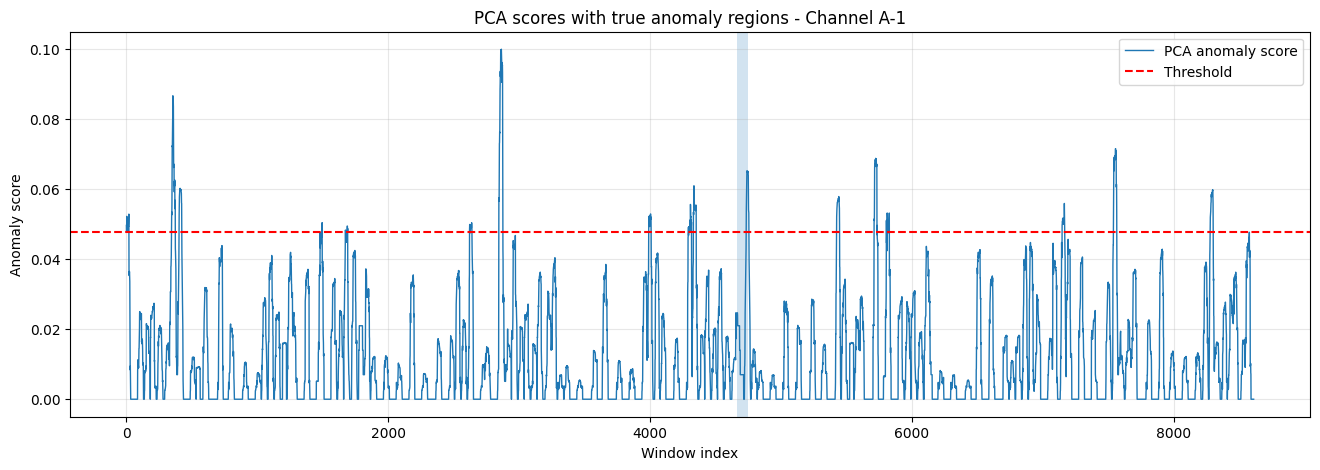

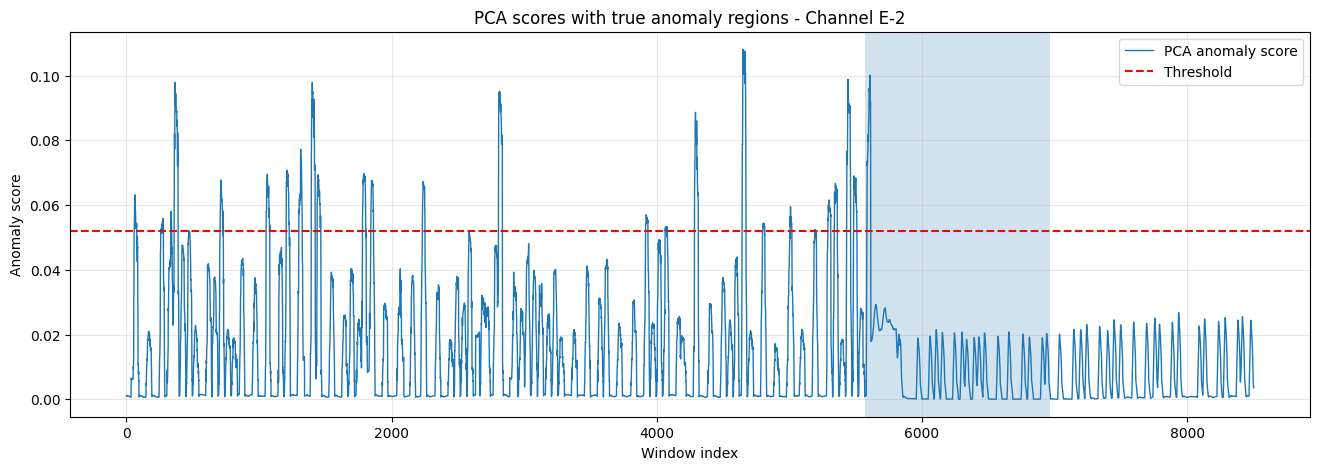

In [82]:
plot_scores_with_anomaly_regions(
    scores=scores_A1,
    y_true=y_true_A1,
    threshold=threshold_A1,
    channel_id='A-1',
    model_name="PCA",
    xlabel="Window index"
)

plot_scores_with_anomaly_regions(
    scores=scores_E2,
    y_true=y_true_E2,
    threshold=threshold_E2,
    channel_id='E-2',
    model_name="PCA",
    xlabel="Window index"
)

The plots for channels A-1 and E-2 clearly expose the reasons behind the PCA baseline's low precision. In **Channel A-1**, while the score does peak during the true anomaly window, it also triggers countless false positives across normal operational periods. The model treats every sudden linear variance as an anomaly, flooding the system with noise.

**Channel E-2** reveals an even more severe structural flaw. During the prolonged anomaly (the wide shaded region), the reconstruction error flatlines near zero. The PCA mistakenly interprets this "frozen" or inactive sensor state as completely normal because it lacks variance, while heavily penalizing the regular, fluctuating behavior that precedes it. This proves that a linear reconstruction model cannot grasp the temporal context or expected duration of these telemetry states, clearly justifying our transition to Deep Learning architectures.

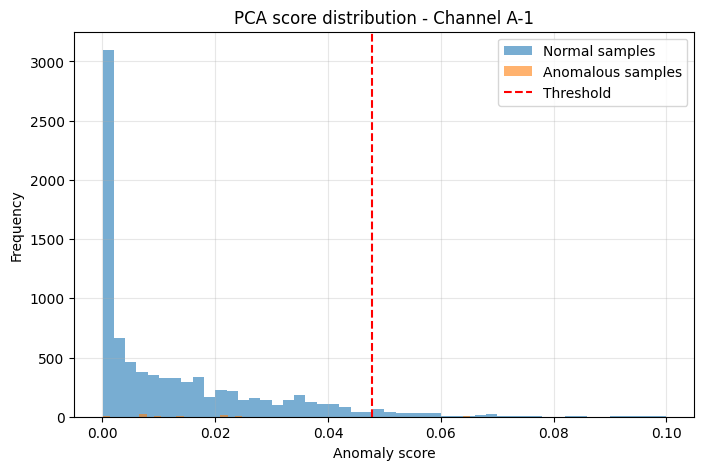

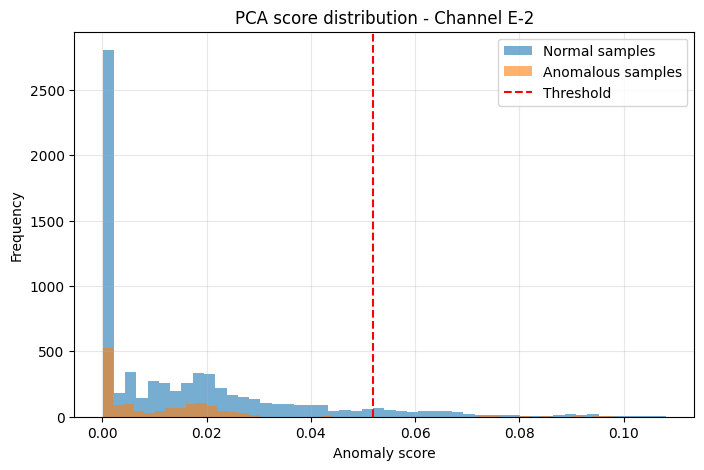

In [83]:
plot_score_distribution(
    scores=scores_A1,
    y_true=y_true_A1,
    threshold=threshold_A1,
    channel_id='A-1',
    model_name="PCA"
)

plot_score_distribution(
    scores=scores_E2,
    y_true=y_true_E2,
    threshold=threshold_E2,
    channel_id='E-2',
    model_name="PCA"
)

The score distribution histograms further confirm the structural limitations of the PCA model. For **Channel A-1**, the scores assigned to the anomalous samples are scattered almost uniformly across the entire score range rather than forming a distinct cluster at the higher end. 

Conversely, **Channel E-2** perfectly illustrates the critical failure observed in the temporal plots: there is a massive spike of anomalous samples receiving the lowest possible anomaly scores (near zero). Because the PCA interprets these "frozen" anomalous states as highly predictable and easy to reconstruct, they fall far below the decision threshold and are completely misclassified as normal behavior.

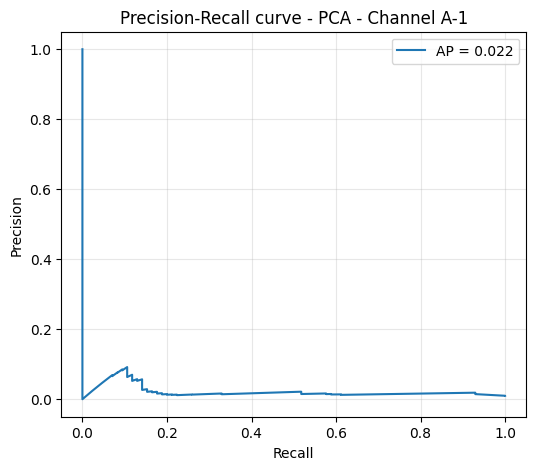

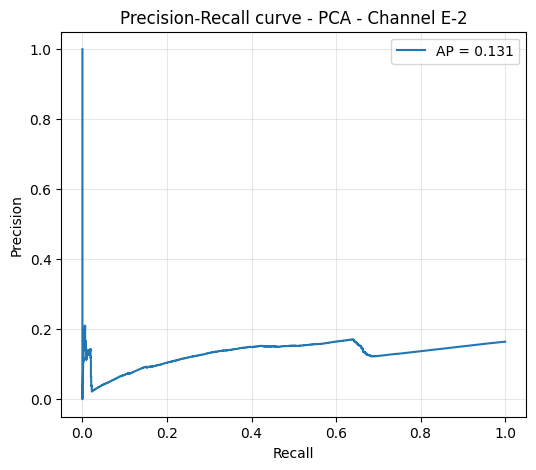

In [84]:
plot_pr_curve(
    scores=scores_A1,
    y_true=y_true_A1,
    channel_id='A-1',
    model_name="PCA"
)

plot_pr_curve(
    scores=scores_E2,
    y_true=y_true_E2,
    channel_id='E-2',
    model_name="PCA"
)

The Precision-Recall curves quantitatively summarize the severe limitations we observed in the previous plots. For **Channel A-1**, the Average Precision (AP) is a dismal 0.022. The curve instantly collapses to near zero even at the lowest recall levels, mathematically confirming that the model's highest anomaly scores are almost entirely false positives triggered by normal operational noise.

**Channel E-2** performs only marginally better with an AP of 0.131. Because the actual "frozen" anomalies received the lowest possible reconstruction errors, the model is forced to misclassify massive amounts of normal data—completely destroying its precision—just to achieve any meaningful recall. These curves definitively prove that a linear, point-wise PCA cannot reliably rank temporal anomalies in this dataset.

### Isolation Forest scoring and threshold selection

Isolation Forest returns a **normality score** through its `decision_function`: higher values correspond to more normal samples, while lower values indicate more isolated and potentially anomalous samples.

$s_{\text{normal}}(x) = \text{decision\_function}(x)$

For consistency with the rest of the anomaly detection pipeline, this score is inverted and converted into an **anomaly score**:

$s_{\text{anom}}(x) = -\text{decision\_function}(x)$

After this transformation, higher values correspond to more anomalous windows, while lower values correspond to more normal windows.

The model is trained with `n_estimators = 200`, meaning that the Isolation Forest is composed of 200 isolation trees. This value is a reasonable compromise between stability and computational cost: using too few trees may produce noisy scores, while increasing the number of trees improves score stability but also increases runtime. Since the dataset is processed channel by channel and the input windows can be high-dimensional after flattening, 200 trees provide a sufficiently robust baseline without making the computation unnecessarily expensive.

The final binary anomaly prediction is obtained by applying a threshold to the anomaly scores. The threshold is not selected on the test set, in order to avoid information leakage. Instead, it is estimated from the validation anomaly scores:

$\tau = Q_{0.99}(s_{\text{anom,val}})$

where $Q_{0.99} is the **99th percentile** of the validation anomaly scores. This means that a test window is classified as anomalous only if its anomaly score is higher than almost all scores observed on the validation set:

$\hat{y}_t =
\begin{cases}
1 & \text{if } s_{\text{anom},t} > \tau \\
0 & \text{otherwise}
\end{cases}$

This choice reflects a semi-supervised anomaly detection setting: the model is trained on historical behavior, and the validation set is used to estimate the upper tail of scores that should still be considered normal. A high quantile such as 0.99 is conservative: it limits the number of false alarms, but it may reduce recall if some true anomalies do not produce extremely high anomaly scores.

For ranking-based metrics such as PR-AUC, the inverted anomaly score $s_{\text{anom}}(x)$ is used directly, because these metrics assume that larger scores correspond to the positive class, i.e. the anomalous class.

Overall, the quantile-based threshold should be interpreted as a simple baseline decision rule. It provides a transparent way to convert continuous anomaly scores into binary anomaly predictions, while more adaptive thresholding strategies can later be compared against it.

In [68]:
def run_isolation_forest_channel(
    channel_id,
    train_data,
    test_data,
    threshold_quantile=0.99,
    n_estimators=200,
    contamination="auto",
    random_state=42
):
    X_train = flatten_windows(train_data[channel_id]["X_train"])
    X_val = flatten_windows(train_data[channel_id]["X_val"])
    X_test = flatten_windows(test_data[channel_id]["X_test"])
    y_test = test_data[channel_id]["y_test"]

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train)

    # IsolationForest decision_function:
    # higher = more normal, lower = more anomalous.
    # We invert it so that higher score = more anomalous.
    val_scores = -model.decision_function(X_val)
    test_scores = -model.decision_function(X_test)

    threshold = np.quantile(val_scores, threshold_quantile)

    metrics = compute_metrics(y_test, test_scores, threshold)

    result = {
        "channel_id": channel_id,
        "model": "IsolationForest",
        "input_dim": X_train.shape[1],
        "n_train_windows": X_train.shape[0],
        "n_val_windows": X_val.shape[0],
        "n_test_windows": X_test.shape[0],
        "threshold_quantile": threshold_quantile,
        "n_estimators": n_estimators,
        "contamination": contamination,
        "score_direction": "higher_is_more_anomalous",
        **metrics
    }

    return result, test_scores, model

def run_isolation_forest_all_channels(
    train_data,
    test_data,
    setting_name,
    threshold_quantile=0.99
):
    results = []
    scores_dict = {}
    models_dict = {}

    for ch in test_data.keys():
        result, scores, model = run_isolation_forest_channel(
            channel_id=ch,
            train_data=train_data,
            test_data=test_data,
            threshold_quantile=threshold_quantile
        )

        result["setting"] = setting_name
        results.append(result)
        scores_dict[ch] = scores
        models_dict[ch] = model

    return pd.DataFrame(results), scores_dict, models_dict

Isolation Forest is trained only on the training split of each telemetry channel. The labeled anomaly intervals are available only for the test set and are not used during training or threshold selection. Therefore, the training phase follows a semi-supervised anomaly detection setting, where the training data are assumed to represent nominal behavior. If some unknown anomalies are present in the training data, they are treated as contamination of the nominal reference distribution, which is a realistic limitation of unsupervised anomaly detection.

In [ ]:
iforest_no_pca_df, iforest_no_pca_scores, iforest_no_pca_models = run_isolation_forest_all_channels(
    train_data=preprocessed_data,
    test_data=test_preprocessed_data,
    setting_name="no_pca",
    threshold_quantile=0.98
)

iforest_pca_df, iforest_pca_scores, iforest_pca_models = run_isolation_forest_all_channels(
    train_data=preprocessed_data_pca,
    test_data=test_preprocessed_data_pca,
    setting_name="pca",
    threshold_quantile=0.98
)

In [ ]:
iforest_results_df = pd.concat(
    [iforest_no_pca_df, iforest_pca_df],
    ignore_index=True
)

display(iforest_results_df)

,channel_id,model,input_dim,n_train_windows,n_val_windows,n_test_windows,threshold_quantile,n_estimators,contamination,score_direction,precision,recall,f1,pr_auc,threshold,predicted_anomaly_ratio,setting
0,A-1,IsolationForest,570,2275,547,8611,0.98,200,auto,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.007537,-0.044728,0.022297,no_pca
1,A-2,IsolationForest,540,2089,501,7885,0.98,200,auto,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.011359,-0.023389,0.014331,no_pca
2,A-3,IsolationForest,540,2159,519,8176,0.98,200,auto,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.019303,-0.032357,0.015656,no_pca
3,A-4,IsolationForest,540,2123,509,8051,0.98,200,auto,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.012858,-0.026715,0.014657,no_pca
4,A-5,IsolationForest,330,535,112,4664,0.98,200,auto,higher_is_more_anomalous,0.010935,1.000000,0.021633,0.013611,-0.152131,1.000000,no_pca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,R-1,IsolationForest,90,2270,546,7215,0.98,200,auto,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.011227,-0.203982,0.050173,pca
100,S-1,IsolationForest,150,2225,535,7302,0.98,200,auto,higher_is_more_anomalous,0.010582,0.004464,0.006279,0.068042,-0.038658,0.025883,pca
101,T-1,IsolationForest,30,2271,546,8583,0.98,200,auto,higher_is_more_anomalous,0.049104,0.048177,0.048636,0.118389,0.103983,0.175580,pca
102,T-2,IsolationForest,120,2255,542,8596,0.98,200,auto,higher_is_more_anomalous,0.100496,0.045378,0.062524,0.159866,-0.067978,0.093765,pca


In [ ]:
iforest_results_df.groupby("setting")[[
    "precision", "recall", "f1", "pr_auc", "predicted_anomaly_ratio"
]].mean()

,precision,recall,f1,pr_auc,predicted_anomaly_ratio
setting,,,,,
no_pca,0.132582,0.116111,0.066984,0.152464,0.081976
pca,0.261129,0.248003,0.174763,0.248463,0.133039


In [ ]:
scores_A1 = iforest_no_pca_scores['A-1']
y_true_A1 = test_preprocessed_data['A-1']["y_test"]
threshold_A1 = iforest_no_pca_df[iforest_no_pca_df["channel_id"] == 'A-1'].iloc[0]["threshold"]


scores_E2 = iforest_no_pca_scores['E-2']
y_true_E2 = test_preprocessed_data['E-2']["y_test"]
threshold_E2 = iforest_no_pca_df[iforest_no_pca_df["channel_id"] == 'E-2'].iloc[0]["threshold"]

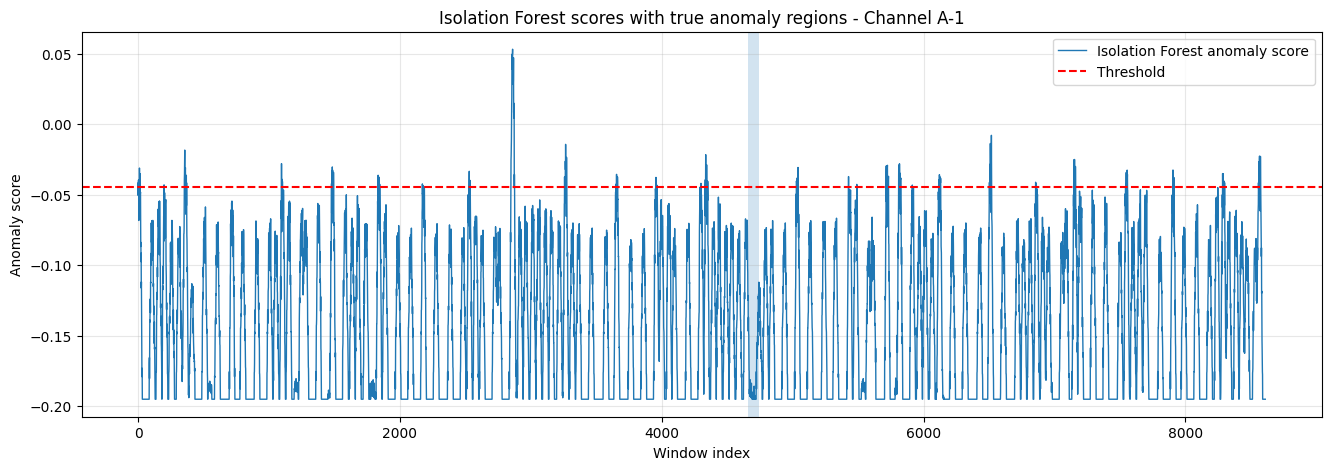

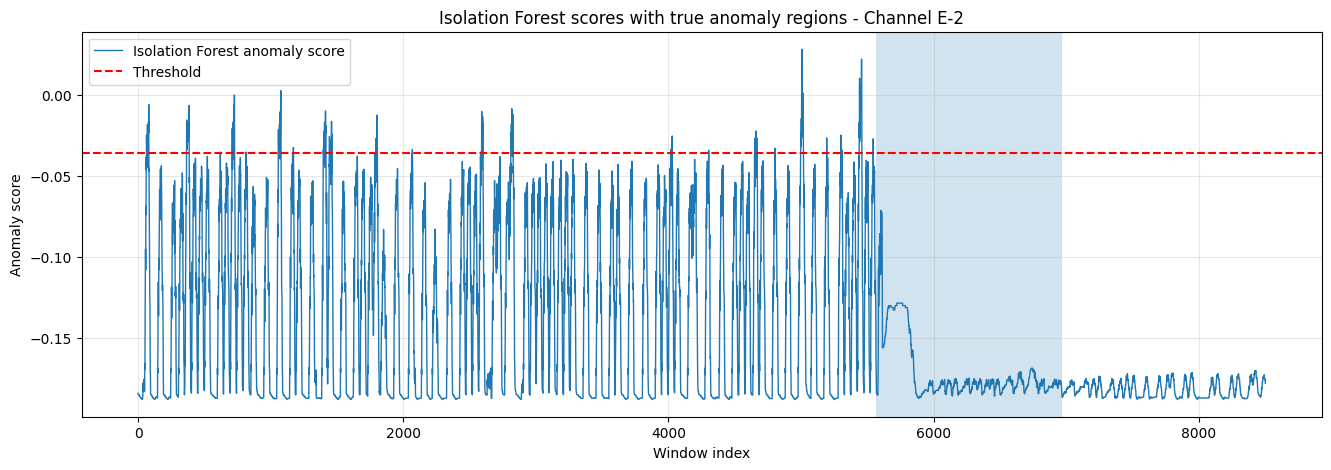

In [ ]:
plot_scores_with_anomaly_regions(
    scores=scores_A1,
    y_true=y_true_A1,
    threshold=threshold_A1,
    channel_id='A-1',
    model_name="Isolation Forest",
    xlabel="Window index"
)

plot_scores_with_anomaly_regions(
    scores=scores_E2,
    y_true=y_true_E2,
    threshold=threshold_E2,
    channel_id='E-2',
    model_name="Isolation Forest",
    xlabel="Window index"
)

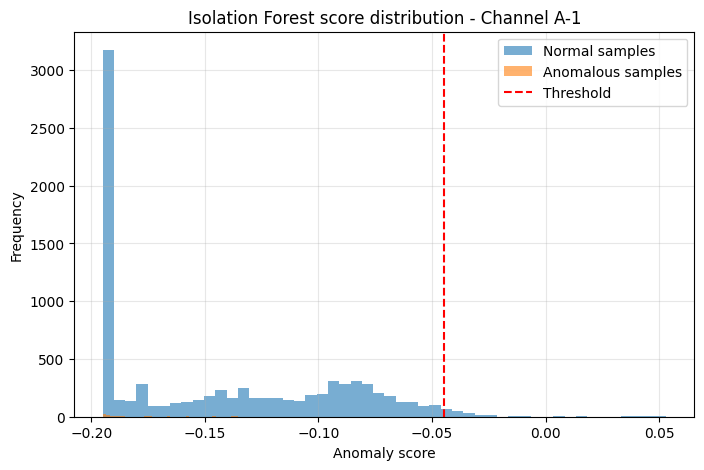

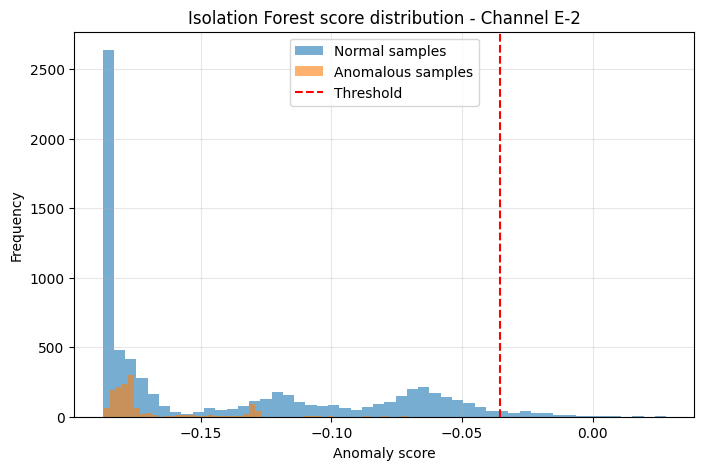

In [ ]:
plot_score_distribution(
    scores=scores_A1,
    y_true=y_true_A1,
    threshold=threshold_A1,
    channel_id='A-1',
    model_name="Isolation Forest"
)

plot_score_distribution(
    scores=scores_E2,
    y_true=y_true_E2,
    threshold=threshold_E2,
    channel_id='E-2',
    model_name="Isolation Forest"
)

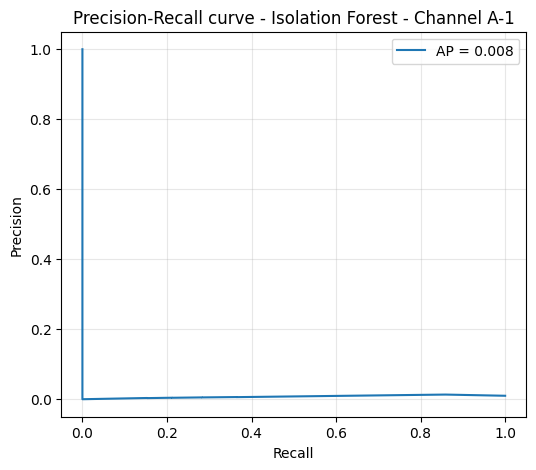

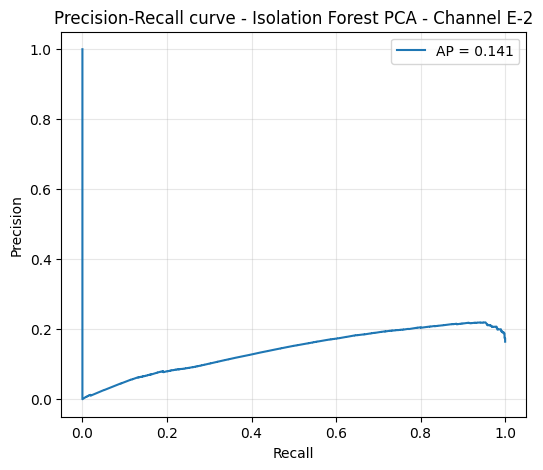

In [ ]:
plot_pr_curve(
    scores=scores_A1,
    y_true=y_true_A1,
    channel_id='A-1',
    model_name="Isolation Forest"
)

plot_pr_curve(
    scores=scores_E2,
    y_true=y_true_E2,
    channel_id='E-2',
    model_name="Isolation Forest PCA"
)

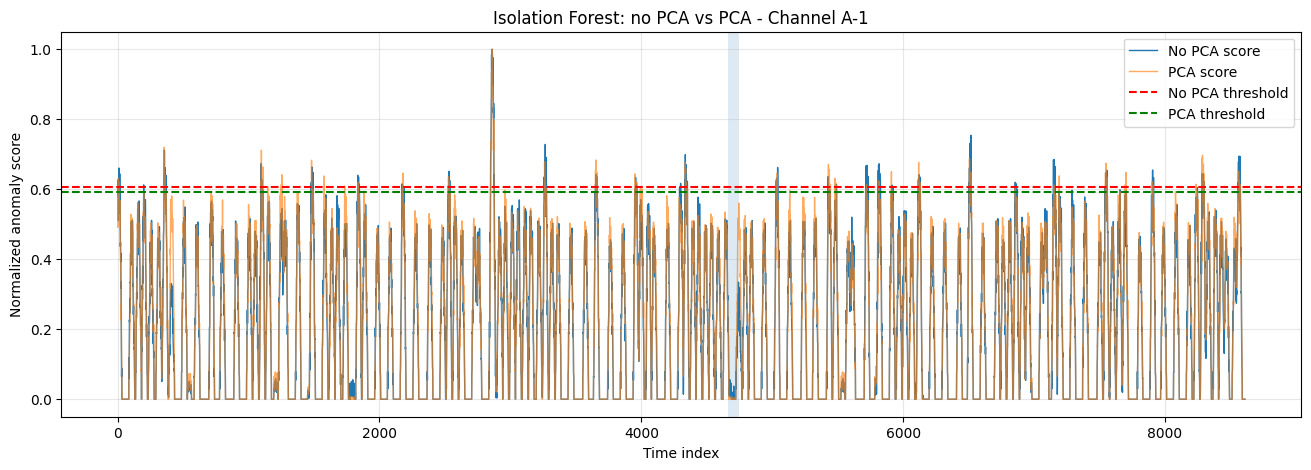

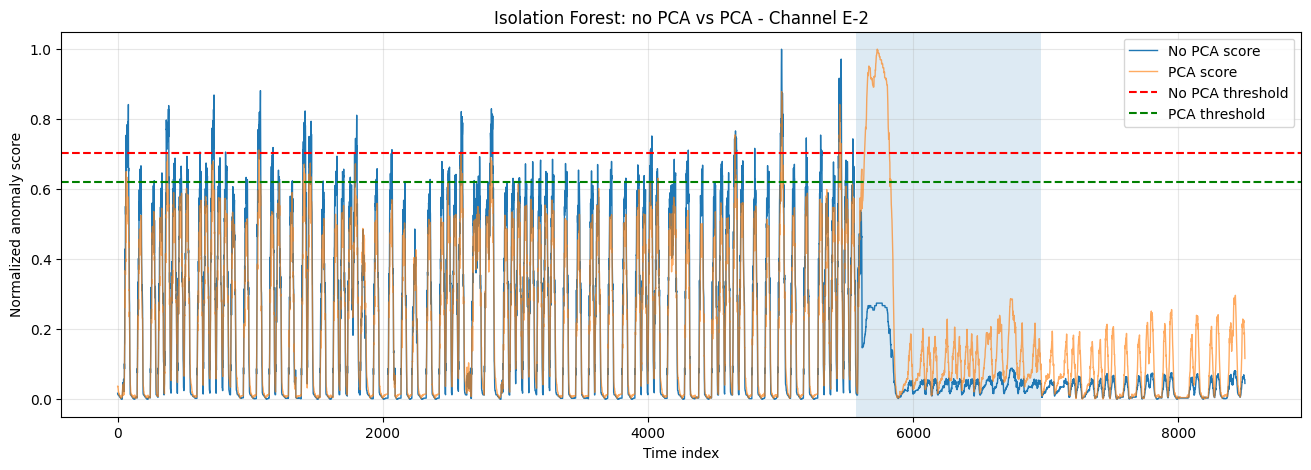

In [ ]:
threshold_A1_pca = iforest_pca_df[iforest_pca_df["channel_id"] == 'A-1'].iloc[0]["threshold"]
threshold_E2_pca = iforest_pca_df[iforest_pca_df["channel_id"] == 'E-2'].iloc[0]["threshold"]

plot_model_comparison_pca_vs_no_pca(
    channel_id='A-1',
    scores_no_pca=iforest_no_pca_scores['A-1'],
    scores_pca=iforest_pca_scores['A-1'],
    y_true=y_true_A1,
    threshold_no_pca=threshold_A1,
    threshold_pca=threshold_A1_pca,
    model_name="Isolation Forest"
)

plot_model_comparison_pca_vs_no_pca(
    channel_id='E-2',
    scores_no_pca=iforest_no_pca_scores['E-2'],
    scores_pca=iforest_pca_scores['E-2'],
    y_true=y_true_E2,
    threshold_no_pca=threshold_E2,
    threshold_pca=threshold_E2_pca,
    model_name="Isolation Forest"
)

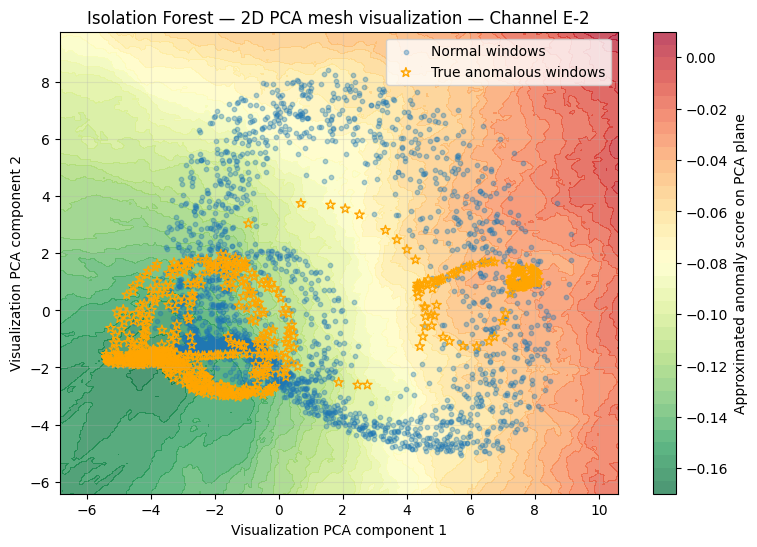

In [ ]:
#Without PCA in preprocessing
plot_iforest_2d_mesh(
    channel_id="E-2",
    train_data=preprocessed_data,
    test_data=test_preprocessed_data,
    scores_dict=iforest_no_pca_scores,
    fitted_models=iforest_no_pca_models,
    results_df=iforest_no_pca_df
)

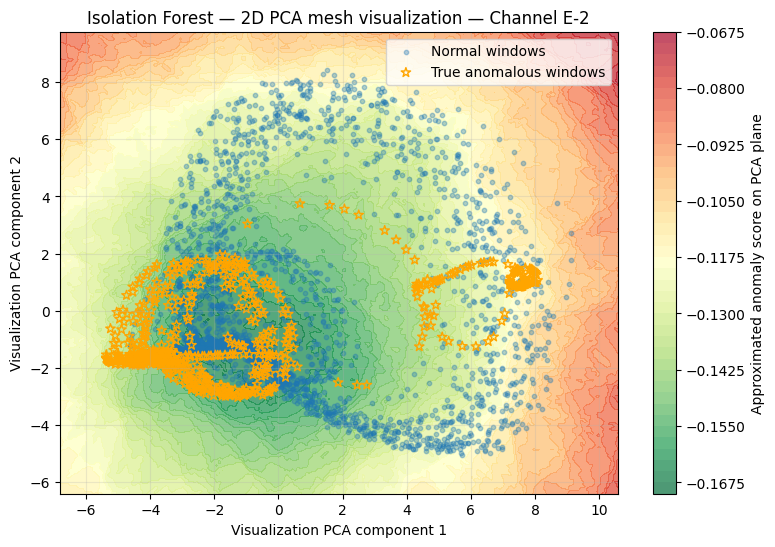

In [ ]:
#With PCA
plot_iforest_2d_mesh(
    channel_id="E-2",
    train_data=preprocessed_data_pca,
    test_data=test_preprocessed_data_pca,
    scores_dict=iforest_pca_scores,
    fitted_models=iforest_pca_models,
    results_df=iforest_pca_df
)

### Interpretation of Isolation Forest results: contextual anomaly A-1 vs point-type anomaly E-2

Isolation Forest was used as a simple baseline to test whether anomalous telemetry windows can be detected as statistically rare samples in the flattened window space. Each temporal window is flattened and treated as an independent high-dimensional point. The Isolation Forest `decision_function` is inverted so that larger values correspond to larger anomaly scores:

$s_{\text{anom}}(x) = - \text{decision\_function}(x)$

Therefore, the ideal behavior would be the following: inside the labeled anomalous regions, the anomaly score should increase clearly and cross the selected threshold, while outside the anomaly regions the score should remain mostly below the threshold. In the score-distribution plots, the anomalous-window distribution should be shifted to the right with respect to the normal-window distribution. In the Precision-Recall curve, a good detector should maintain high precision as recall increases, producing an AP/PR-AUC substantially higher than the anomaly prevalence. Finally, in the 2D visualization, anomalous windows should preferably lie in regions associated with higher anomaly scores, separated from the main cloud of normal windows.

The results show that this ideal behavior is not achieved.

Channel `A-1` is labeled as a **contextual anomaly**, meaning that the anomalous behavior is not necessarily identifiable from a single isolated value, but depends on the temporal context in which the signal evolves. This is precisely the kind of anomaly that Isolation Forest is not well designed to capture. In the score-over-time plot, the shaded anomalous interval does not correspond to a clear and persistent increase in the anomaly score. Instead, high anomaly-score peaks appear throughout the sequence, including many regions outside the labeled anomaly. This means that the model is detecting isolated or rare windows, but these rare windows are not aligned with the ground-truth contextual anomaly. The score-distribution plot confirms this problem: normal and anomalous windows are not clearly separated, and the anomalous distribution is not strongly shifted beyond the threshold. The Precision-Recall curve is also extremely poor for `A-1`, with an AP around `0.008`, which is close to random behavior given the very small anomaly ratio. This indicates that the anomaly scores do not provide a useful ranking of anomalous versus normal windows for this channel.

Channel `E-2` is labeled as a **point-type anomaly**, but this does not mean that the anomaly is a single timestep. The label indicates the anomaly class, while the annotated anomaly sequence is still an interval. In this case, the interval is approximately from timestep/window region `5598` to `6995`, so the anomalous region is long. Since `E-2` is a point-type anomaly, one might expect Isolation Forest to work better than in `A-1`, because point anomalies should be closer to the notion of rare or isolated samples. However, the plots show that this is not the case. In the score-over-time plot, the anomaly score does not consistently rise above the threshold during the labeled interval. On the contrary, after the beginning of the labeled region, the score becomes lower and more stable. This suggests that the anomalous segment is not perceived by Isolation Forest as a collection of isolated windows. It may instead correspond to a regime change or to a stable abnormal state, which is not necessarily rare in the flattened feature space. The score-distribution plot supports this interpretation: the anomalous scores overlap strongly with the normal scores, and many anomalous windows remain below the decision threshold. The Precision-Recall curve for `E-2` is better than for `A-1`, but still weak, with AP around `0.066`, meaning that the model has only limited ability to rank anomalous windows above normal ones.

The overall metrics confirm the weakness of Isolation Forest as a baseline on this dataset. Without PCA preprocessing, the average results are approximately:

$
\text{precision}=0.133,\quad
\text{recall}=0.116,\quad
\text{F1}=0.067,\quad
\text{PR-AUC}=0.152
$

With PCA preprocessing, the results improve:

$
\text{precision}=0.261,\quad
\text{recall}=0.248,\quad
\text{F1}=0.175,\quad
\text{PR-AUC}=0.248
$

This shows that PCA helps the Isolation Forest baseline by reducing dimensionality and possibly removing redundant or noisy directions. However, even with PCA, the performance remains limited. The F1 score is still low, recall remains below `0.25`, and the predicted anomaly ratio increases to about `0.133`, meaning that the model flags more windows as anomalous but still does not align strongly with the ground-truth anomaly intervals. Therefore, PCA improves the baseline but does not solve the core modeling problem.

The qualitative 2D PCA mesh visualization further supports this conclusion, but it must be interpreted carefully. This plot projects flattened windows onto a 2D PCA space and shows an approximate anomaly-score landscape. Ideally, anomalous windows should appear concentrated in high-score regions and clearly separated from normal windows. Instead, for `E-2`, the anomalous windows overlap substantially with the main cloud of normal windows and do not occupy a clearly distinct high-score region. This suggests again that the anomaly is not well represented as a simple isolated region in the static feature space. However, this plot is only qualitative: the colored background is obtained after projecting the data into two dimensions and approximating the score surface on that plane. It should therefore be used only as a visual explanation, not as formal evidence. The quantitative conclusions must rely on the test metrics and Precision-Recall analysis.

Overall, Isolation Forest does not work well for either `A-1` or `E-2`, although for different reasons. For `A-1`, the failure is expected because contextual anomalies require temporal interpretation, while Isolation Forest treats each flattened window as an independent static point. For `E-2`, the failure is more informative: even a point-type anomaly may correspond to a long abnormal regime rather than to isolated extreme windows. In both cases, the model detects statistical rarity, but the NASA SMAP labels often describe temporal, contextual, or regime-change anomalies. This mismatch explains why Isolation Forest is useful as a transparent baseline, but not sufficient as the main anomaly detection method. These results motivate the use of a forecasting-based model, where anomalies are detected from prediction errors and therefore from deviations with respect to expected temporal evolution.

In [ ]:
def make_var_dataset(X, lag=5):
    """
    Build a VAR-style supervised dataset.

    For each timestep t, the input is:
        [x_{t-lag}, ..., x_{t-1}]

    and the target is:
        x_t

    Parameters
    ----------
    X : np.ndarray
        Time series array of shape (T, n_features).
    lag : int
        Number of autoregressive lags.

    Returns
    -------
    X_lagged : np.ndarray
        Lagged inputs of shape (T-lag, lag*n_features).
    y_target : np.ndarray
        Targets of shape (T-lag, n_features).
    """
    X_lagged = []
    y_target_bin = []
    y_target_con = []

    for t in range(lag, len(X)):
        past_block = X[t-lag:t]          # shape: (lag, n_features)
        X_lagged.append(past_block.ravel())
        y_target.append(X[t])

    return np.array(X_lagged), np.array(y_target)

def align_labels_to_var_targets(y_raw, lag=5):
    """
    Align raw timestep labels with VAR targets.

    Since the first prediction is for timestep t=lag,
    the first label is y_raw[lag].
    """
    return np.array(y_raw[lag:], dtype=int)

def get_binary_indices(X_train_matrix):
    n_features = X_train_matrix.shape[1]
    binary_idx = []
    cont_idx = []

    for i in range(n_features):
        col = X_train_matrix[i]
        n_unique = np.unique(X_train_matrix).size()

        if n_unique <= 2:
            binary_idx.append(i)
        else:
            cont_idx.append(i)
    
    return binary_idx, cont_idx

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SMAPChannelDataset(Dataset):
    def __init__(self, X_window, y_target, binary_ndx, cont_ndx):
        self.X = torch.tensor(X_window, dtype = torch.float32)

        y_cont_np = y_target[:, cont_ndx]
        y_bin_np = y_target[:, binary_ndx]

        self.y_cont = torch.tensor(y_cont_np, dtype = torch.float32)
        self.y_bin = torch.tensor(y_bin_np, dtype = torch.float32)

        self.y_bin_np = torch.where(self.y_bin == -1, 0.0, self.y_bin)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, key):
        return self.X[key], self.y_cont[key], self.y_bin[key]

In [ ]:
def run_VAR_mlp_channel(
    channel_id,
    train_data,
    test_data,
    batch_size = 64,
    lag=5,
    alpha=1.0,
    threshold_quantile=0.99
):
    X_train_seq = train_data[channel_id]["X_train_seq"]
    X_val_seq = train_data[channel_id]["X_val_seq"]
    X_test_seq = test_data[channel_id]["X_test_seq"]
    y_test_raw = test_data[channel_id]["y_test_raw"]

    binary_ndx, cont_ndx = get_binary_indices(X_train_seq)

    X_train_var, y_train_var = make_var_dataset(X_train_seq, lag=lag)
    X_val_var, y_val_var = make_var_dataset(X_val_seq, lag=lag)
    X_test_var, y_test_var = make_var_dataset(X_test_seq, lag=lag)

    y_test = align_labels_to_var_targets(y_test_raw, lag=lag)

    train_dataset = SMAPChannelDataset(X_train_var, y_train_var, binary_ndx, cont_ndx)
    val_dataset = SMAPChannelDataset(X_val_var, y_val_var, binary_ndx, cont_ndx)
    test_dataset = SMAPChannelDataset(X_test_var, y_test_var, binary_ndx, cont_ndx)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
    test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
    

### VAR forecasting baseline for anomaly detection

A Vector Autoregression model is used as a forecasting-based baseline. Unlike Isolation Forest, which treats each flattened temporal window as an independent static point, VAR explicitly models the temporal dependency of the multivariate telemetry signal.

For each telemetry channel, the current vector is predicted from its previous $p$ lagged values:

$x_t = c + A_1x_{t-1} + A_2x_{t-2} + \dots + A_px_{t-p} + \varepsilon_t$

where $x_t \in \mathbb{R}^d$ is the multivariate telemetry vector at time $t$, $p$ is the lag order, and $A_1,\dots,A_p$ are coefficient matrices.

The model is used for anomaly detection through its forecasting residuals. If the observed telemetry vector is difficult to predict from its recent past, the prediction error becomes large and the corresponding timestep is considered potentially anomalous:

$s_t = \frac{1}{d}\sum_{j=1}^{d}(x_{t,j} - \hat{x}_{t,j})^2$

where \(s_t\) is the anomaly score. Larger scores therefore correspond to more anomalous observations.

In practice, a regularized VAR formulation is used through Ridge regression. This is still equivalent to a linear autoregressive model on lagged multivariate observations, but Ridge regularization improves numerical stability when the number of variables and lags is high.

In [ ]:
def make_var_dataset(X, lag=5):
    """
    Build a VAR-style supervised dataset.

    For each timestep t, the input is:
        [x_{t-lag}, ..., x_{t-1}]

    and the target is:
        x_t

    Parameters
    ----------
    X : np.ndarray
        Time series array of shape (T, n_features).
    lag : int
        Number of autoregressive lags.

    Returns
    -------
    X_lagged : np.ndarray
        Lagged inputs of shape (T-lag, lag*n_features).
    y_target : np.ndarray
        Targets of shape (T-lag, n_features).
    """
    X_lagged = []
    y_target_bin = []
    y_target_con = []

    for t in range(lag, len(X)):
        past_block = X[t-lag:t]          # shape: (lag, n_features)
        X_lagged.append(past_block.ravel())
        y_target.append(X[t])

    return np.array(X_lagged), np.array(y_target)

def align_labels_to_var_targets(y_raw, lag=5):
    """
    Align raw timestep labels with VAR targets.

    Since the first prediction is for timestep t=lag,
    the first label is y_raw[lag].
    """
    return np.array(y_raw[lag:], dtype=int)

In [ ]:
def run_var_ridge_channel(
    channel_id,
    train_data,
    test_data,
    lag=5,
    alpha=1.0,
    threshold_quantile=0.99
):
    # -------------------------
    # Retrieve processed sequences
    # -------------------------
    X_train_seq = train_data[channel_id]["X_train_seq"]
    X_val_seq = train_data[channel_id]["X_val_seq"]
    X_test_seq = test_data[channel_id]["X_test_seq"]
    y_test_raw = test_data[channel_id]["y_test_raw"]

    # -------------------------
    # Build VAR datasets
    # -------------------------
    X_train_var, y_train_var = make_var_dataset(X_train_seq, lag=lag)
    X_val_var, y_val_var = make_var_dataset(X_val_seq, lag=lag)
    X_test_var, y_test_var = make_var_dataset(X_test_seq, lag=lag)

    y_test = align_labels_to_var_targets(y_test_raw, lag=lag)

    assert len(X_test_var) == len(y_test), (
        f"{channel_id}: mismatch between VAR test samples and labels. "
        f"{len(X_test_var)} vs {len(y_test)}"
    )

    # -------------------------
    # Fit regularized VAR
    # -------------------------
    model = Ridge(alpha=alpha)
    model.fit(X_train_var, y_train_var)

    # -------------------------
    # Forecast
    # -------------------------
    y_val_pred = model.predict(X_val_var)
    y_test_pred = model.predict(X_test_var)

    # -------------------------
    # Forecasting error = anomaly score
    # -------------------------
    val_scores = np.mean((y_val_var - y_val_pred) ** 2, axis=1)
    test_scores = np.mean((y_test_var - y_test_pred) ** 2, axis=1)

    threshold = np.quantile(val_scores, threshold_quantile)

    metrics = compute_metrics(
        y_true=y_test,
        scores=test_scores,
        threshold=threshold
    )

    result = {
        "channel_id": channel_id,
        "model": "VAR_Ridge",
        "lag": lag,
        "alpha": alpha,
        "input_dim": X_train_var.shape[1],
        "target_dim": y_train_var.shape[1],
        "n_train_samples": X_train_var.shape[0],
        "n_val_samples": X_val_var.shape[0],
        "n_test_samples": X_test_var.shape[0],
        "threshold_quantile": threshold_quantile,
        "score_direction": "higher_is_more_anomalous",
        **metrics
    }

    output = {
        "model": model,
        "val_scores": val_scores,
        "test_scores": test_scores,
        "y_test": y_test,
        "y_test_true_values": y_test_var,
        "y_test_pred_values": y_test_pred
    }

    return result, output

def run_var_ridge_all_channels(
    train_data,
    test_data,
    setting_name,
    lag=5,
    alpha=1.0,
    threshold_quantile=0.99
):
    results = []
    outputs = {}

    for ch in test_data.keys():
        result, output = run_var_ridge_channel(
            channel_id=ch,
            train_data=train_data,
            test_data=test_data,
            lag=lag,
            alpha=alpha,
            threshold_quantile=threshold_quantile
        )

        result["setting"] = setting_name
        results.append(result)
        outputs[ch] = output

    return pd.DataFrame(results), outputs

In [ ]:
VAR_LAG = 5
VAR_ALPHA = 1.0
VAR_THRESHOLD_QUANTILE = 0.99

var_no_pca_df, var_no_pca_outputs = run_var_ridge_all_channels(
    train_data=preprocessed_data,
    test_data=test_preprocessed_data,
    setting_name="no_pca",
    lag=VAR_LAG,
    alpha=VAR_ALPHA,
    threshold_quantile=VAR_THRESHOLD_QUANTILE
)

var_pca_df, var_pca_outputs = run_var_ridge_all_channels(
    train_data=preprocessed_data_pca,
    test_data=test_preprocessed_data_pca,
    setting_name="pca",
    lag=VAR_LAG,
    alpha=VAR_ALPHA,
    threshold_quantile=VAR_THRESHOLD_QUANTILE
)

var_results_df = pd.concat(
    [var_no_pca_df, var_pca_df],
    ignore_index=True
)

display(var_results_df)

,channel_id,model,lag,alpha,input_dim,target_dim,n_train_samples,n_val_samples,n_test_samples,threshold_quantile,score_direction,precision,recall,f1,pr_auc,threshold,predicted_anomaly_ratio,setting
0,A-1,VAR_Ridge,5,1.0,95,19,2299,571,8635,0.99,higher_is_more_anomalous,0.007407,0.011765,0.009091,0.011296,0.806827,0.015634,no_pca
1,A-2,VAR_Ridge,5,1.0,90,18,2113,525,7909,0.99,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.014327,0.880347,0.007333,no_pca
2,A-3,VAR_Ridge,5,1.0,90,18,2183,543,8200,0.99,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.019271,0.874030,0.005976,no_pca
3,A-4,VAR_Ridge,5,1.0,90,18,2147,533,8075,0.99,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.013776,0.859139,0.011146,no_pca
4,A-5,VAR_Ridge,5,1.0,55,11,559,136,4688,0.99,higher_is_more_anomalous,0.021480,0.882353,0.041938,0.537606,5.920254,0.446886,no_pca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,R-1,VAR_Ridge,5,1.0,15,3,2294,570,7239,0.99,higher_is_more_anomalous,0.000000,0.000000,0.000000,0.011196,0.000102,0.021136,pca
100,S-1,VAR_Ridge,5,1.0,25,5,2249,559,7326,0.99,higher_is_more_anomalous,0.045455,0.006696,0.011673,0.106589,2.968490,0.009009,pca
101,T-1,VAR_Ridge,5,1.0,5,1,2295,570,8607,0.99,higher_is_more_anomalous,0.274194,0.011068,0.021277,0.193383,0.146910,0.007203,pca
102,T-2,VAR_Ridge,5,1.0,20,4,2279,566,8620,0.99,higher_is_more_anomalous,0.123762,0.014006,0.025164,0.211607,0.026673,0.023434,pca


In [ ]:
var_results_df.groupby("setting")[[
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "predicted_anomaly_ratio"
]].mean()

,precision,recall,f1,pr_auc,predicted_anomaly_ratio
setting,,,,,
no_pca,0.226657,0.174324,0.105122,0.234784,0.108211
pca,0.223956,0.154870,0.105931,0.235218,0.091071


In [ ]:
#Plotting no PCA results
scores_A1_var = var_no_pca_outputs['A-1']["test_scores"]
scores_E2_var = var_no_pca_outputs['E-2']["test_scores"]

y_true_A1_var = var_no_pca_outputs['A-1']["y_test"]
y_true_E2_var = var_no_pca_outputs['E-2']["y_test"]

threshold_A1_var = var_no_pca_df[var_no_pca_df["channel_id"] == 'A-1'].iloc[0]["threshold"]
threshold_E2_var = var_no_pca_df[var_no_pca_df["channel_id"] == 'E-2'].iloc[0]["threshold"]

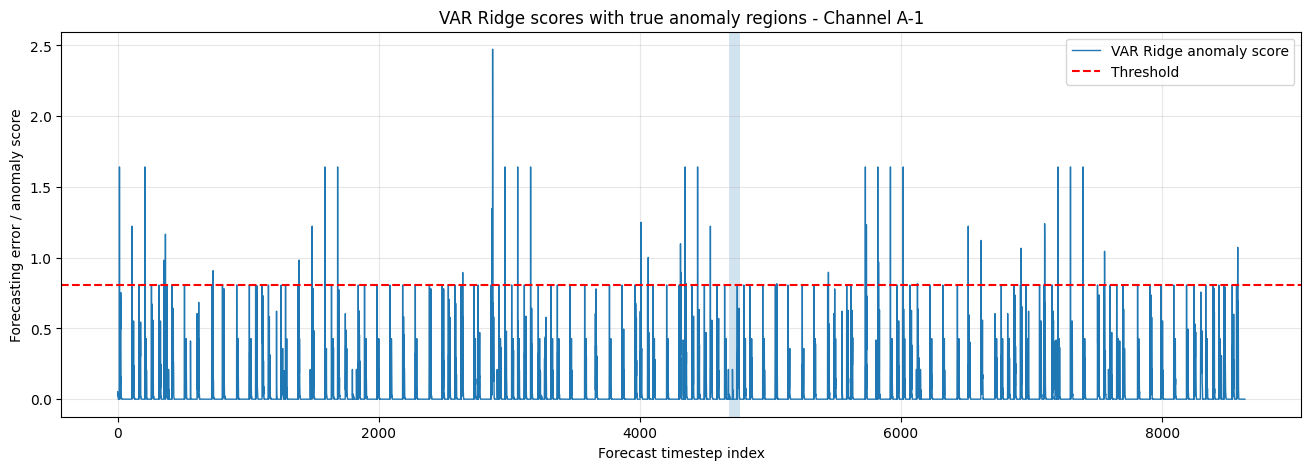

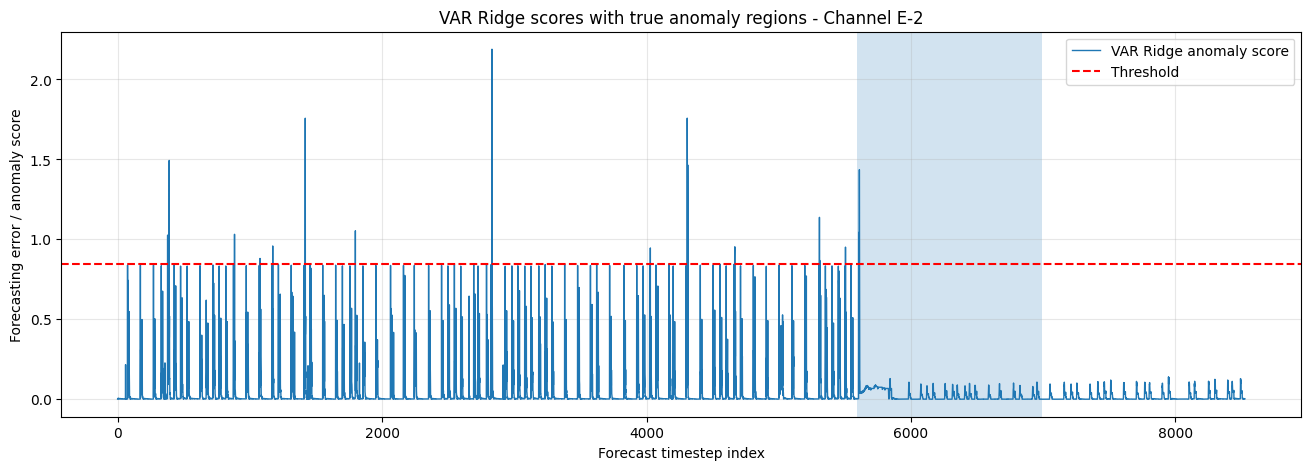

In [ ]:
plot_scores_with_anomaly_regions(
    scores=scores_A1_var,
    y_true=y_true_A1_var,
    threshold=threshold_A1_var,
    channel_id='A-1',
    model_name="VAR Ridge",
    xlabel="Forecast timestep index",
    score_label="Forecasting error / anomaly score"
)

plot_scores_with_anomaly_regions(
    scores=scores_E2_var,
    y_true=y_true_E2_var,
    threshold=threshold_E2_var,
    channel_id='E-2',
    model_name="VAR Ridge",
    xlabel="Forecast timestep index",
    score_label="Forecasting error / anomaly score"
)

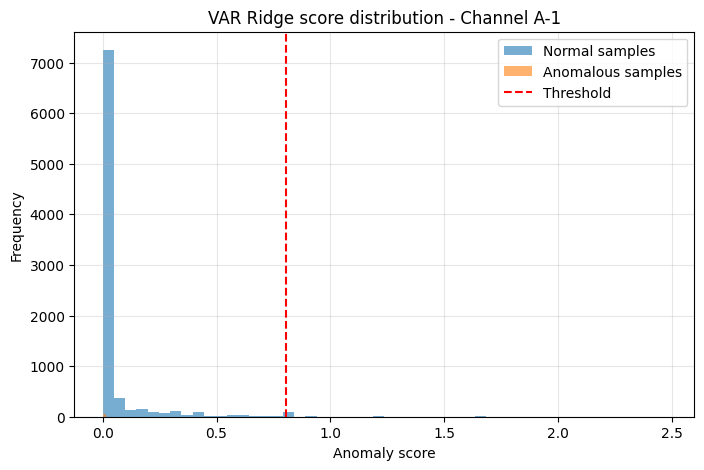

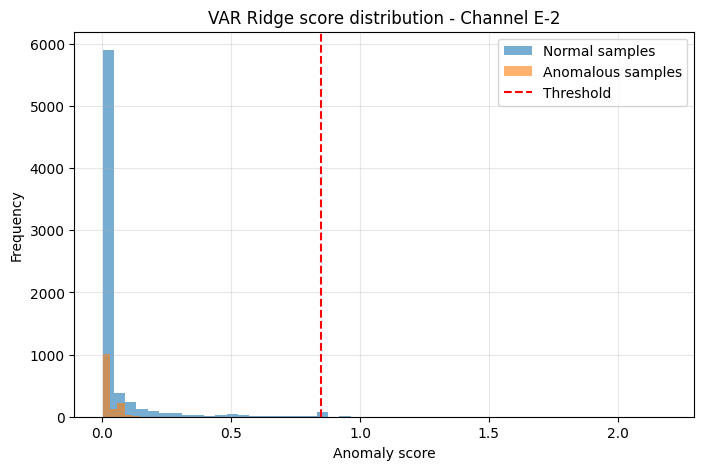

In [ ]:
plot_score_distribution(
    scores=scores_A1_var,
    y_true=y_true_A1_var,
    threshold=threshold_A1_var,
    channel_id='A-1',
    model_name="VAR Ridge"
)

plot_score_distribution(
    scores=scores_E2_var,
    y_true=y_true_E2_var,
    threshold=threshold_E2_var,
    channel_id='E-2',
    model_name="VAR Ridge"
)

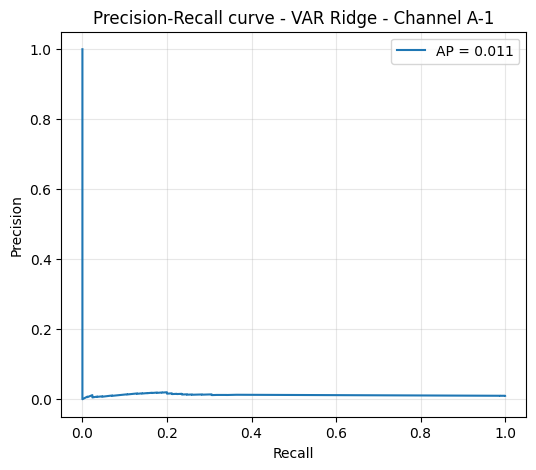

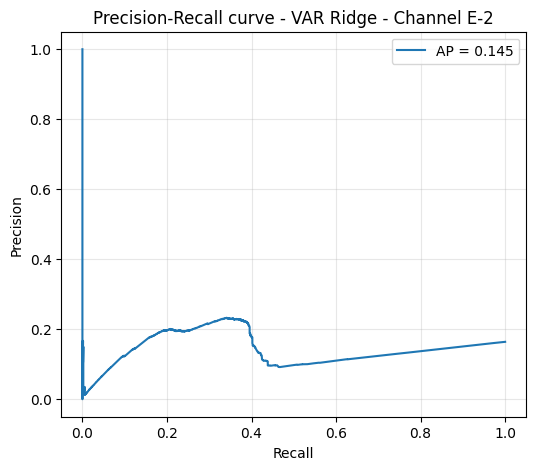

In [ ]:
plot_pr_curve(
    scores=scores_A1_var,
    y_true=y_true_A1_var,
    channel_id='A-1',
    model_name="VAR Ridge"
)

plot_pr_curve(
    scores=scores_E2_var,
    y_true=y_true_E2_var,
    channel_id='E-2',
    model_name="VAR Ridge"
)

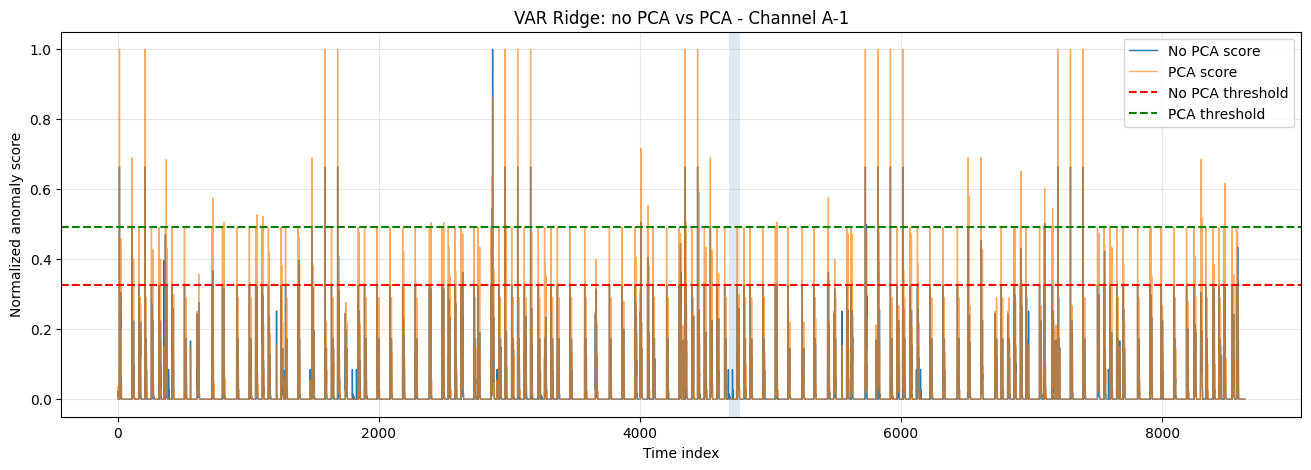

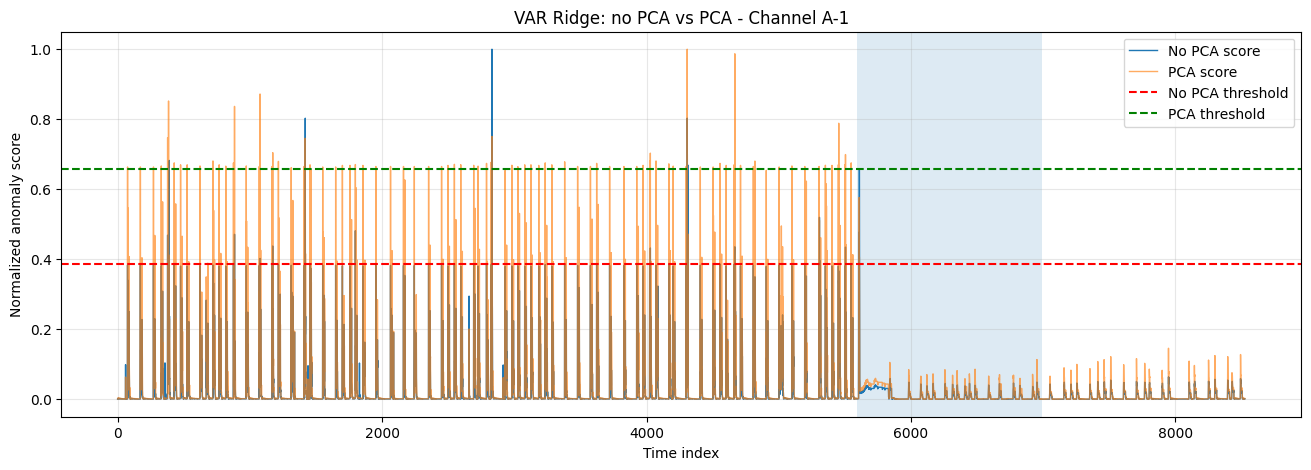

In [ ]:
threshold_A1_var_pca = var_pca_df[var_pca_df["channel_id"] == 'A-1'].iloc[0]["threshold"]
threshold_E2_var_pca = var_pca_df[var_pca_df["channel_id"] == 'E-2'].iloc[0]["threshold"]

plot_model_comparison_pca_vs_no_pca(
    channel_id=ch,
    scores_no_pca=scores_A1_var,
    scores_pca=var_pca_outputs['A-1']["test_scores"],
    y_true=y_true_A1_var,
    threshold_no_pca=threshold_A1_var,
    threshold_pca=threshold_A1_var_pca,
    model_name="VAR Ridge"
)

plot_model_comparison_pca_vs_no_pca(
    channel_id=ch,
    scores_no_pca=scores_E2_var,
    scores_pca=var_pca_outputs['E-2']["test_scores"],
    y_true=y_true_E2_var,
    threshold_no_pca=threshold_E2_var,
    threshold_pca=threshold_E2_var_pca,
    model_name="VAR Ridge"
)